In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("pvathana_project_summary.csv", sep=";")

df["Month"] = pd.to_datetime(
    df["time"], unit="s", utc=True
).dt.strftime("%Y-%m")

print("Projects:", df["project_wocid"].nunique())
print("Commits:", len(df))
df.head()

Projects: 10
Commits: 13268


,project_wocid,commit_sha1,author,time,commit message,Month
0,mucollective_multidy,005dd50bc16720a653f2cee00e786c551a1bf093,Abhraneel Sarma <abhraneelsarma2024@u.northwes...,1603765446,solves #54\n,2020-10
1,mucollective_multidy,0075221fdb8bb0e15b9a4aa25984cc14ad95f93a,Abhraneel Sarma <abhraneelsarma2024@u.northwes...,1645114955,updated docs\n,2022-02
2,mucollective_multidy,00773e3985875d42b894577caf71f722f3abfb65,Abhraneel Sarma <abhsarma@umich.edu>,1562946264,Merge branch 'dev' into no-ds-store,2019-07
3,mucollective_multidy,00b1ff5cfa60395631845e4a1a28dad3dd8ac740,Abhraneel Sarma <abhraneelsarma2024@u.northwe...,1596691697,block exec logic fix\n,2020-08
4,mucollective_multidy,00c48a03d1631fa015d4889f9a2b3e23fa5bb89e,Abhraneel Sarma <abhraneel@Abhraneels-MacBook-...,1620663885,eval fixes\n,2021-05


In [2]:
monthly_data = {}

for project in df["project_wocid"].unique():
    project_df = df[df["project_wocid"] == project]

    monthly = project_df.groupby("Month").size()

    all_months = pd.period_range(
        start=monthly.index.min(),
        end=monthly.index.max(),
        freq="M"
    )

    monthly = monthly.reindex(all_months.astype(str), fill_value=0)

    monthly_df = monthly.reset_index()
    monthly_df.columns = ["Month", "#Commits"]

    monthly_data[project] = monthly_df

    print(project, ":", monthly_df["#Commits"].sum(), "commits")

mucollective_multidy : 120 commits
askurz_doing-bayesian-data-analysis-in-brms-and-the-tidyverse : 258 commits
esmvalgroup_esmvaltool : 10353 commits
rtiinternational_smart : 540 commits
jannisborn_covid_detector : 140 commits
overlordgolddragon_ssqueezepy : 127 commits
rust-bio_rust-bio : 770 commits
ccsb-scripps_autodock-gpu : 370 commits
ebivariation_eva-tools : 310 commits
opendatacube_datacube-alchemist : 280 commits


In [3]:
for project, monthly_df in monthly_data.items():
    filename = f"pvathana_commits_timeseries_{project}.csv"

    monthly_df.to_csv(filename, sep=";", index=False)

    print("Saved:", filename)

Saved: pvathana_commits_timeseries_mucollective_multidy.csv
Saved: pvathana_commits_timeseries_askurz_doing-bayesian-data-analysis-in-brms-and-the-tidyverse.csv
Saved: pvathana_commits_timeseries_esmvalgroup_esmvaltool.csv
Saved: pvathana_commits_timeseries_rtiinternational_smart.csv
Saved: pvathana_commits_timeseries_jannisborn_covid_detector.csv
Saved: pvathana_commits_timeseries_overlordgolddragon_ssqueezepy.csv
Saved: pvathana_commits_timeseries_rust-bio_rust-bio.csv
Saved: pvathana_commits_timeseries_ccsb-scripps_autodock-gpu.csv
Saved: pvathana_commits_timeseries_ebivariation_eva-tools.csv
Saved: pvathana_commits_timeseries_opendatacube_datacube-alchemist.csv


In [4]:
for project in monthly_data:
    filename = f"pvathana_commits_timeseries_{project}.csv"
    monthly_df = pd.read_csv(filename, sep=";")

    plt.figure(figsize=(10, 5))

    plt.plot(
        monthly_df["Month"],
        monthly_df["#Commits"],
        marker="o",
        linestyle="-",
        markersize=2
    )

    plt.xlabel("Time (YYYY-MM)")
    plt.ylabel("Number of Commits")
    plt.title(project)
    plt.grid(True)

    plt.xticks(range(0, len(monthly_df), 12), rotation=45)
    plt.tight_layout()

    plt.savefig(f"pvathana_timeseries_{project}.png", dpi=300)
    plt.close()

    print("Saved:", project)

Saved: mucollective_multidy
Saved: askurz_doing-bayesian-data-analysis-in-brms-and-the-tidyverse
Saved: esmvalgroup_esmvaltool
Saved: rtiinternational_smart
Saved: jannisborn_covid_detector
Saved: overlordgolddragon_ssqueezepy
Saved: rust-bio_rust-bio
Saved: ccsb-scripps_autodock-gpu
Saved: ebivariation_eva-tools
Saved: opendatacube_datacube-alchemist


mucollective_multidy


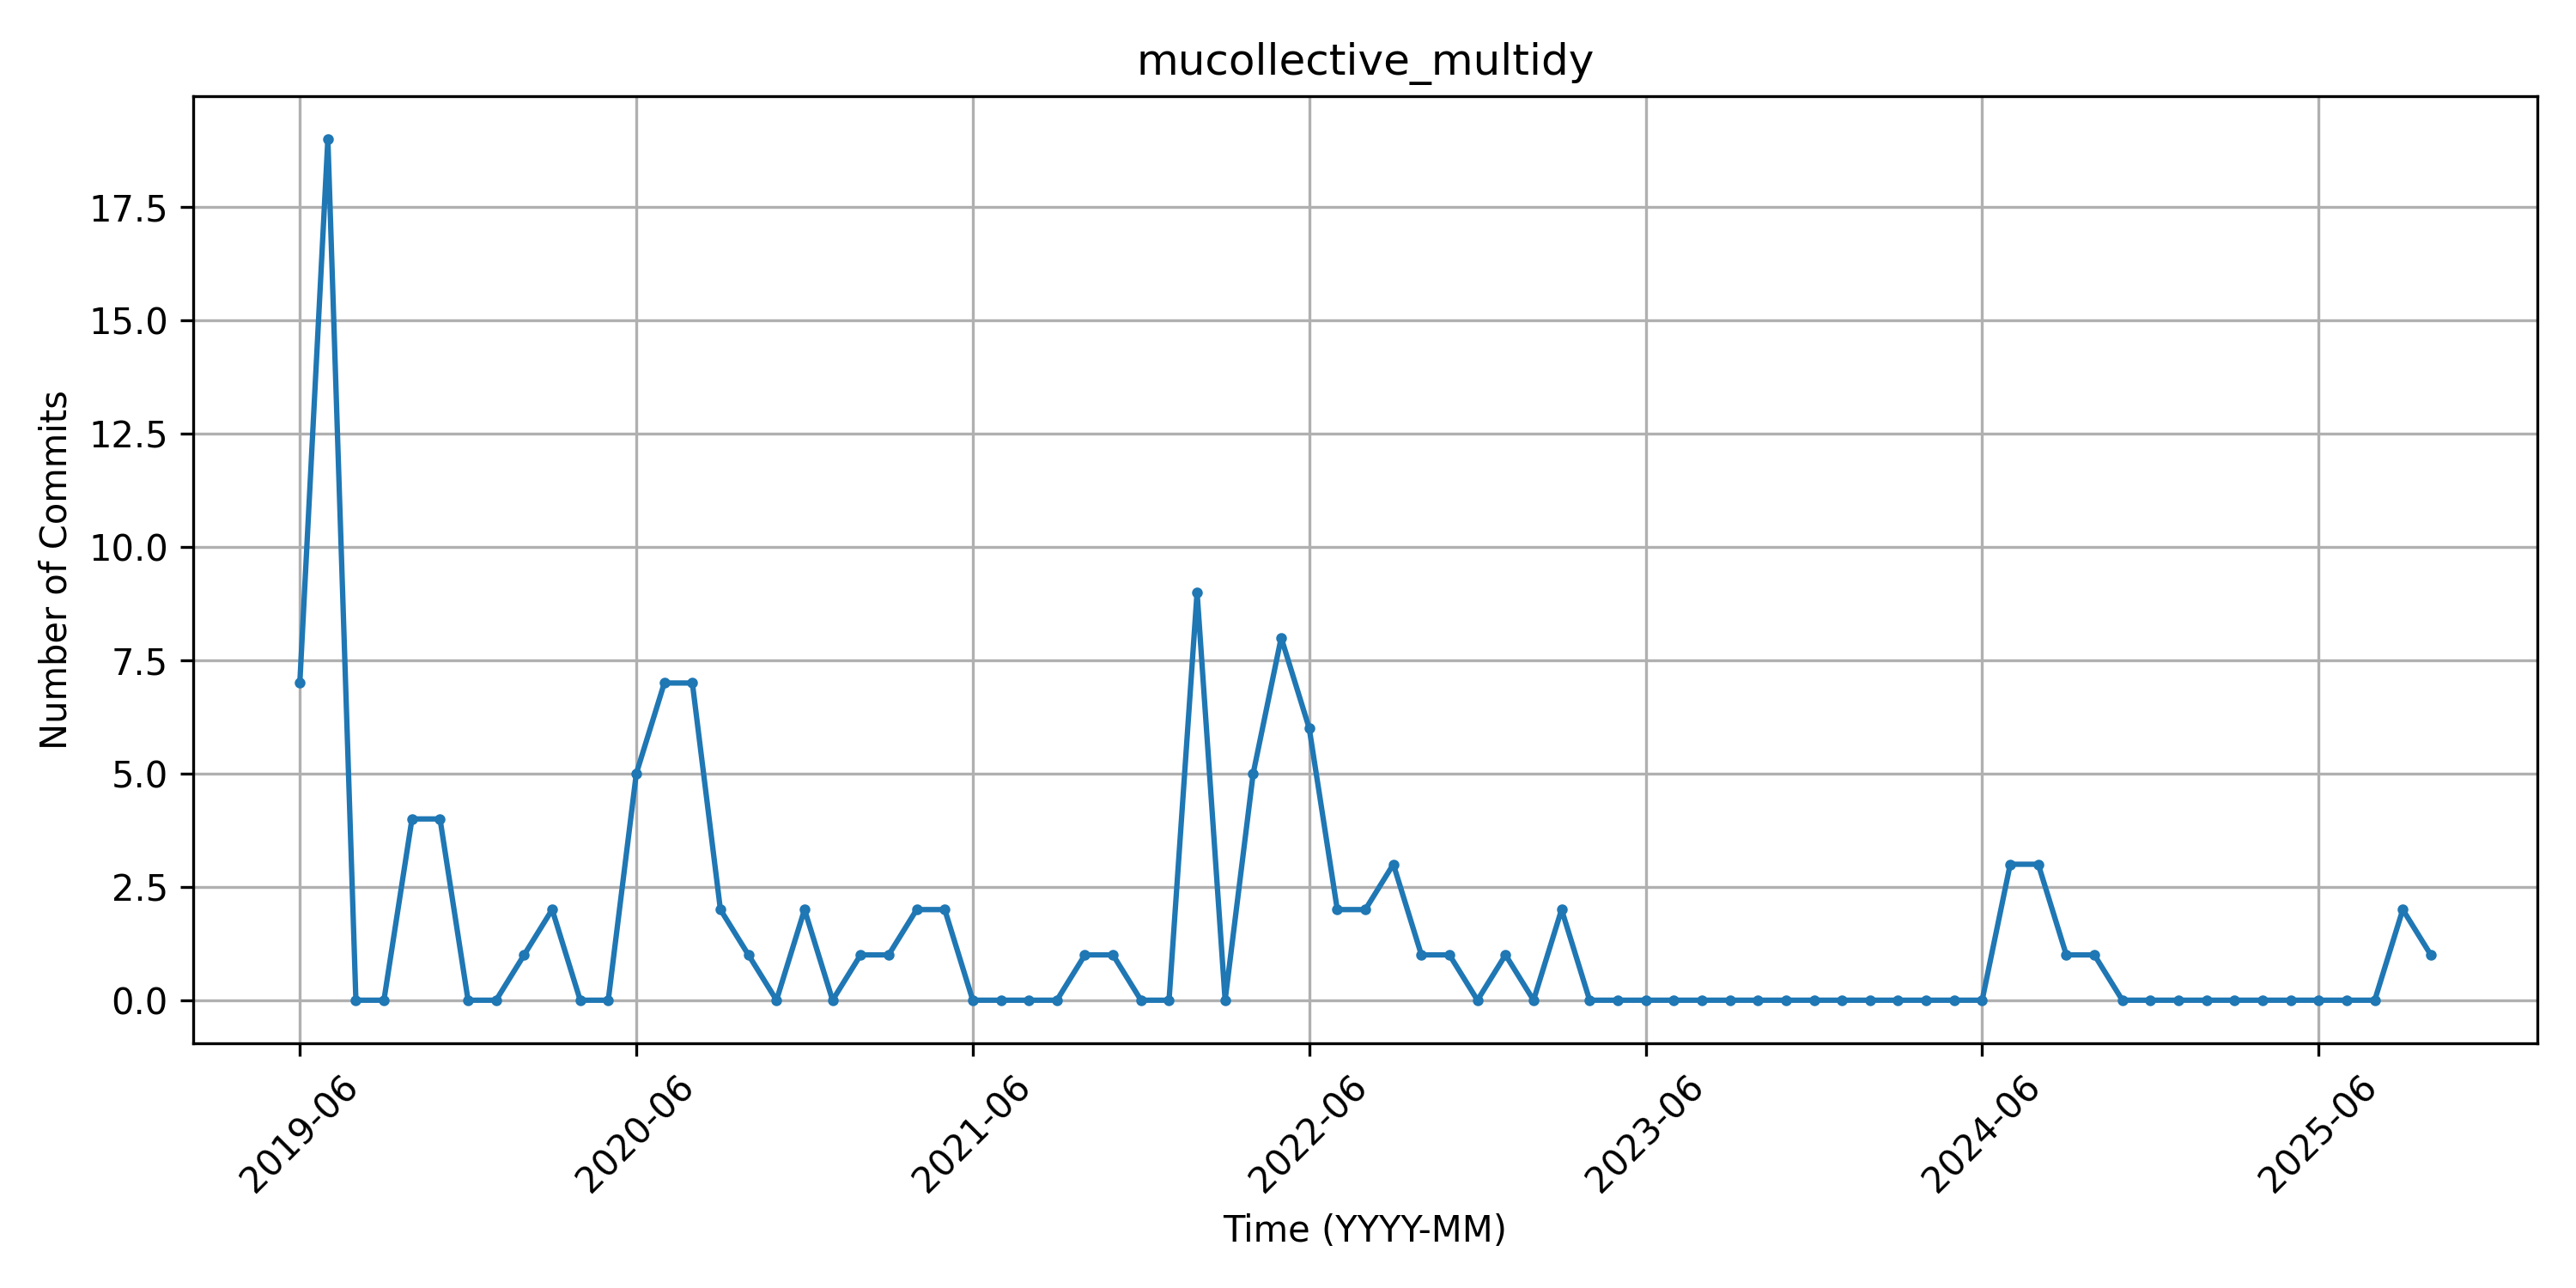

askurz_doing-bayesian-data-analysis-in-brms-and-the-tidyverse


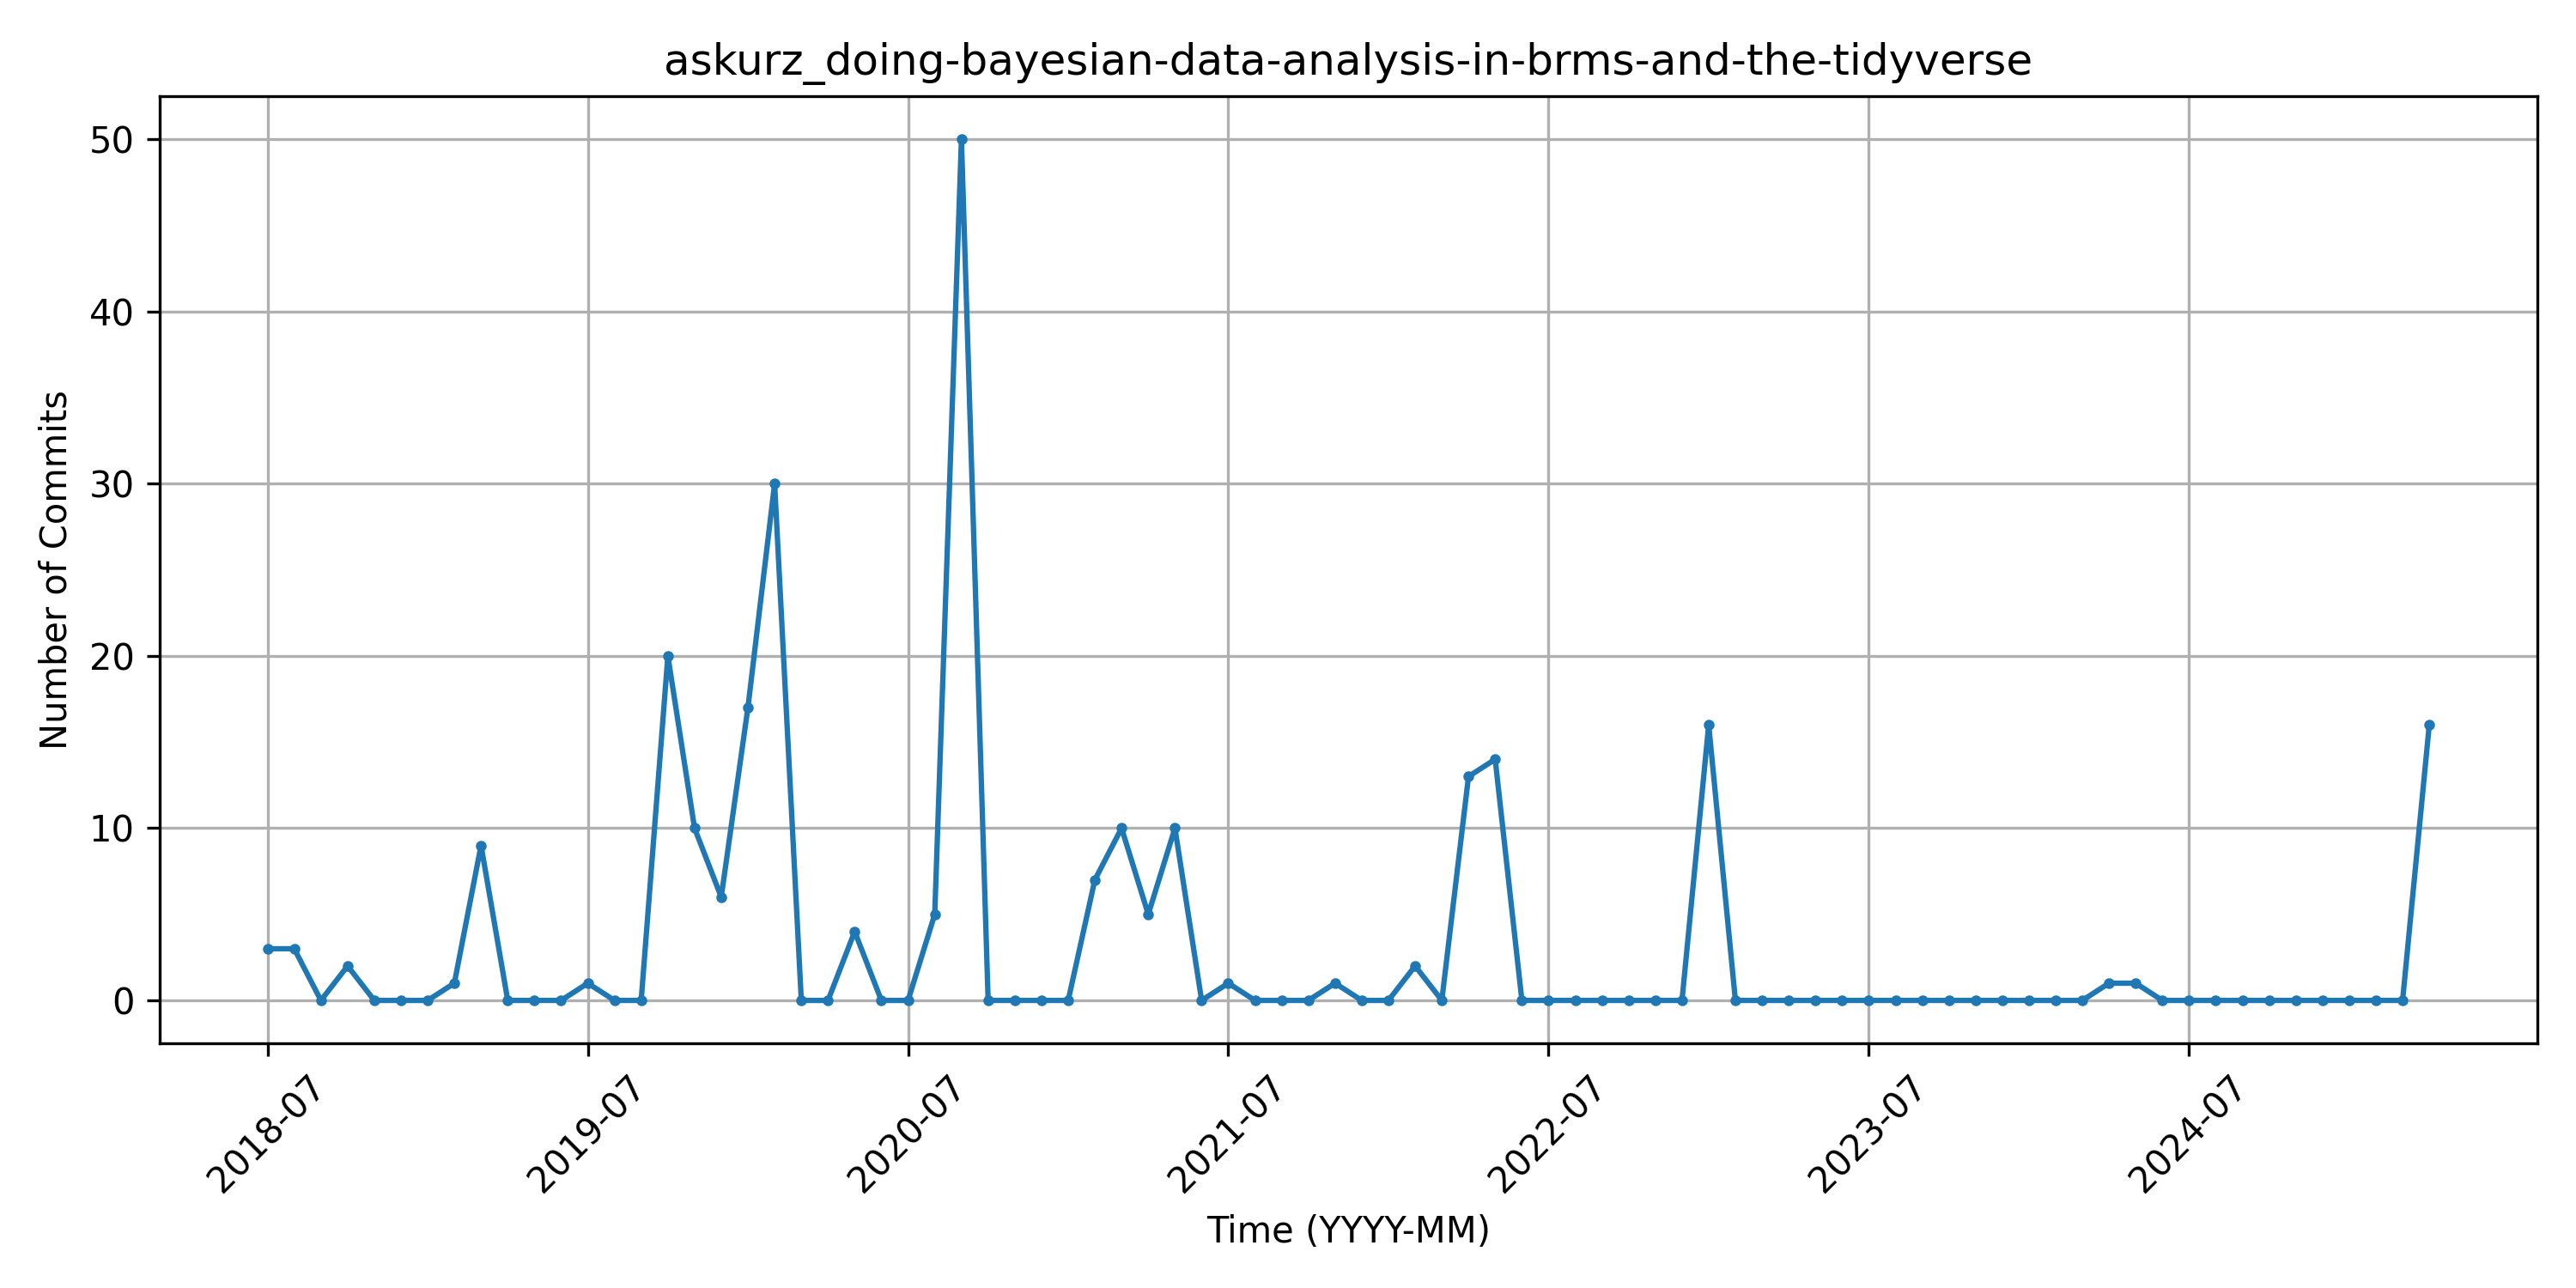

esmvalgroup_esmvaltool


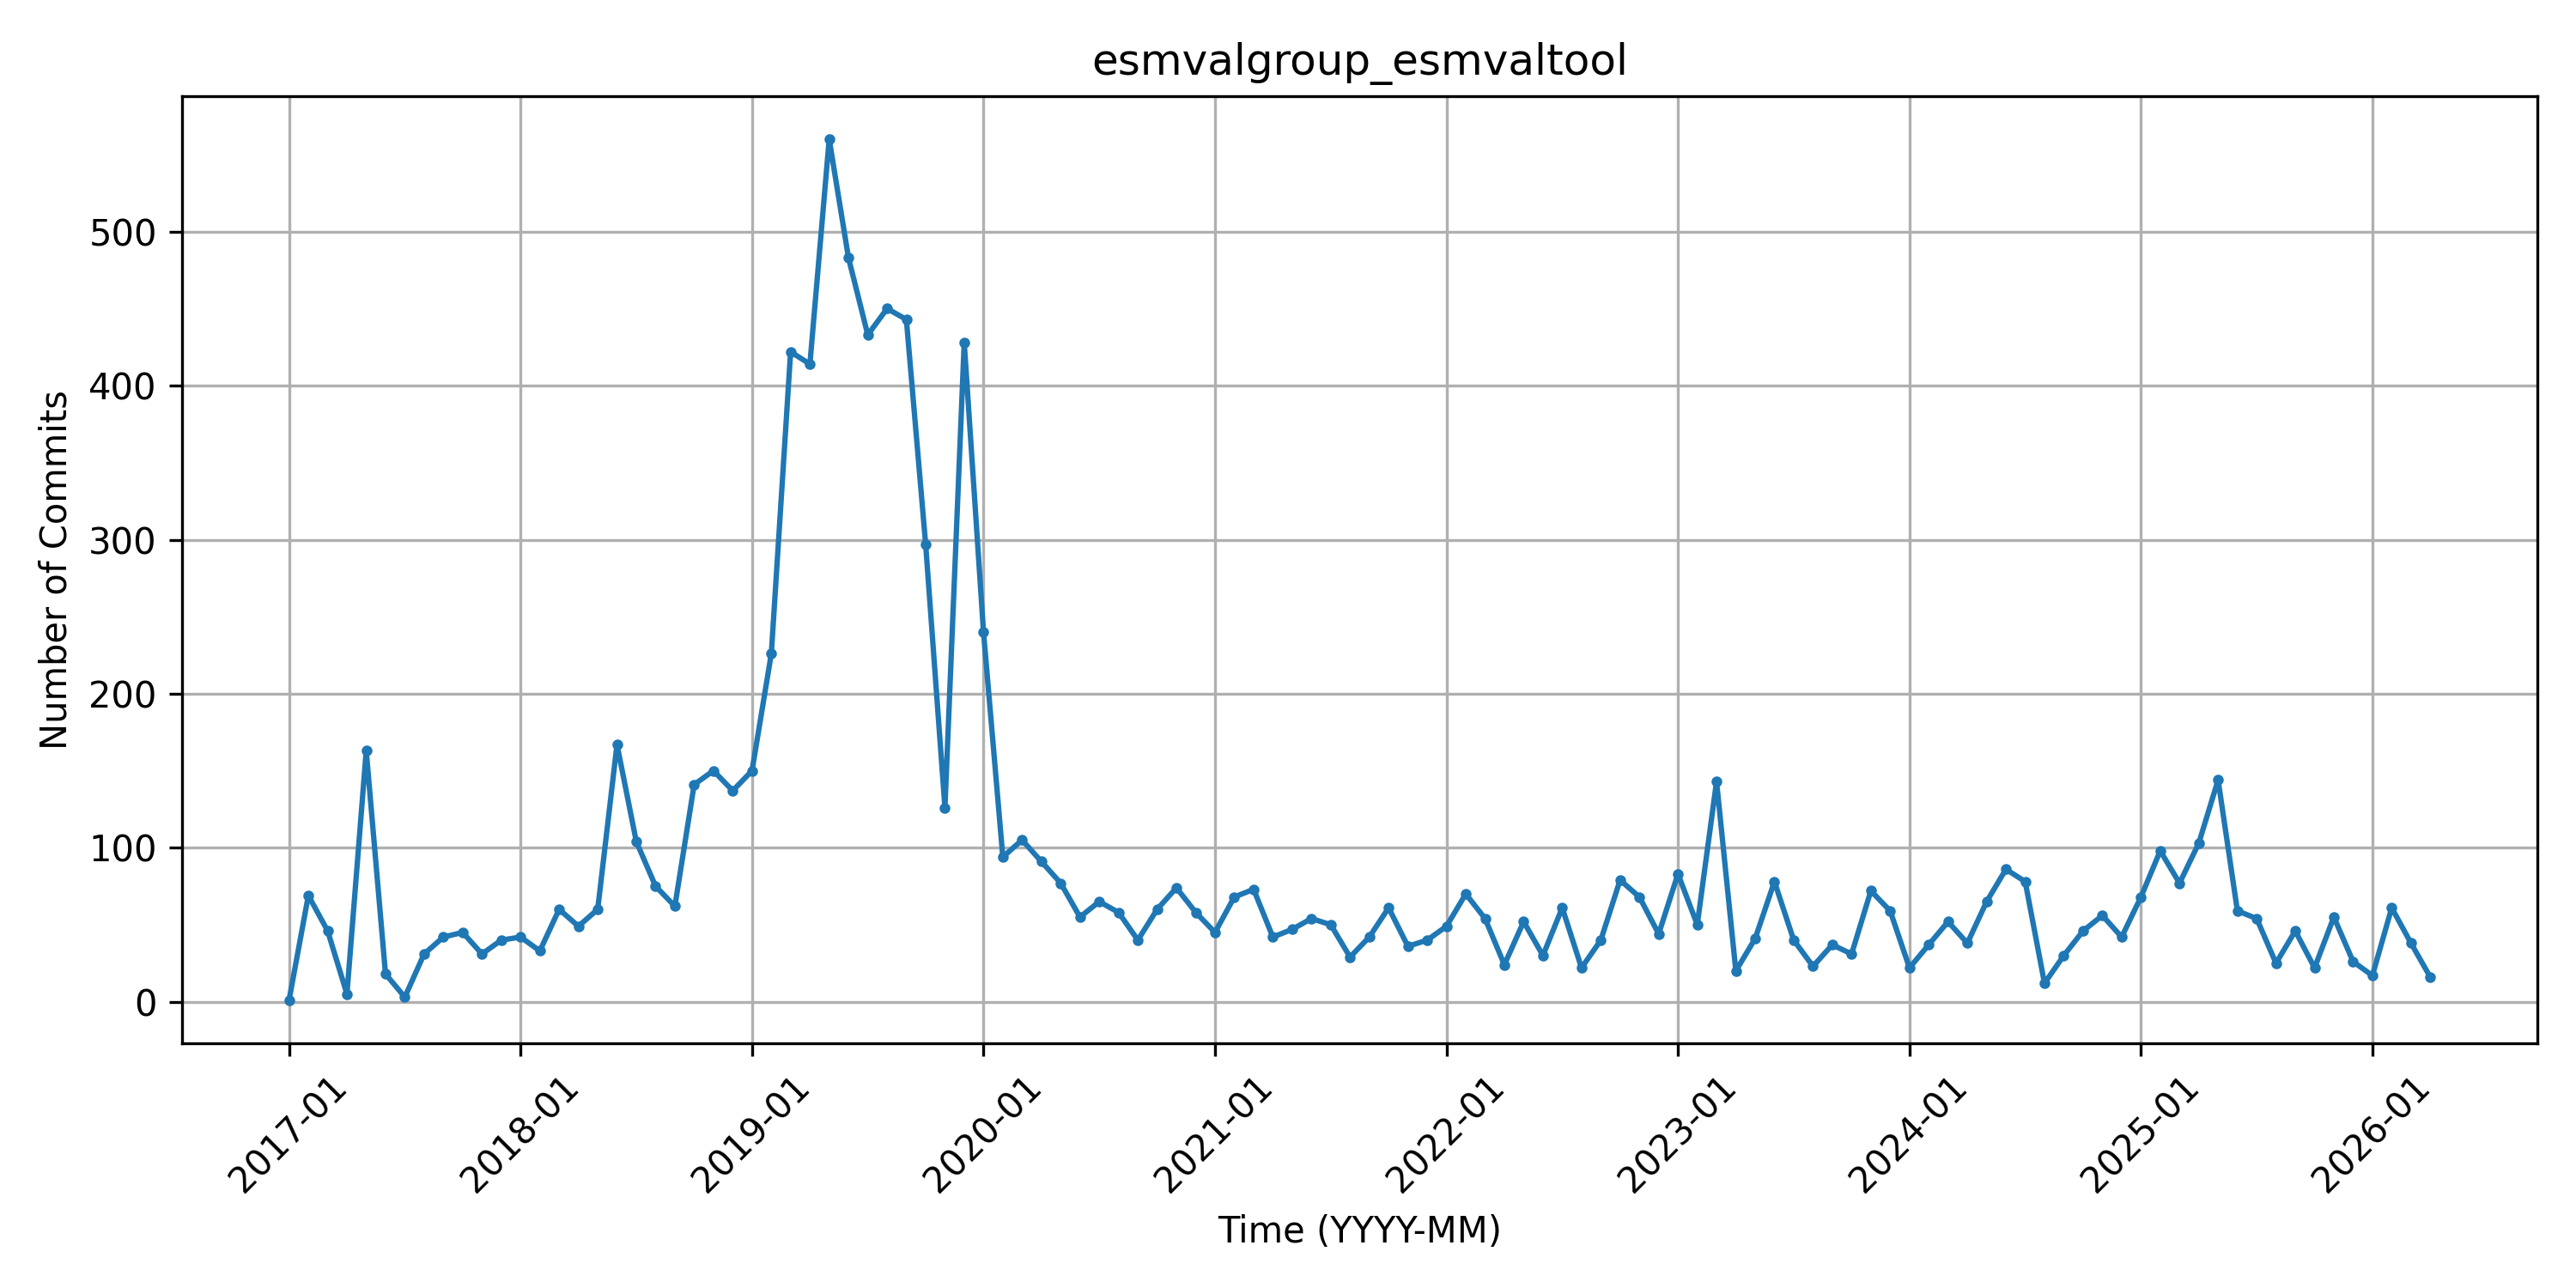

rtiinternational_smart


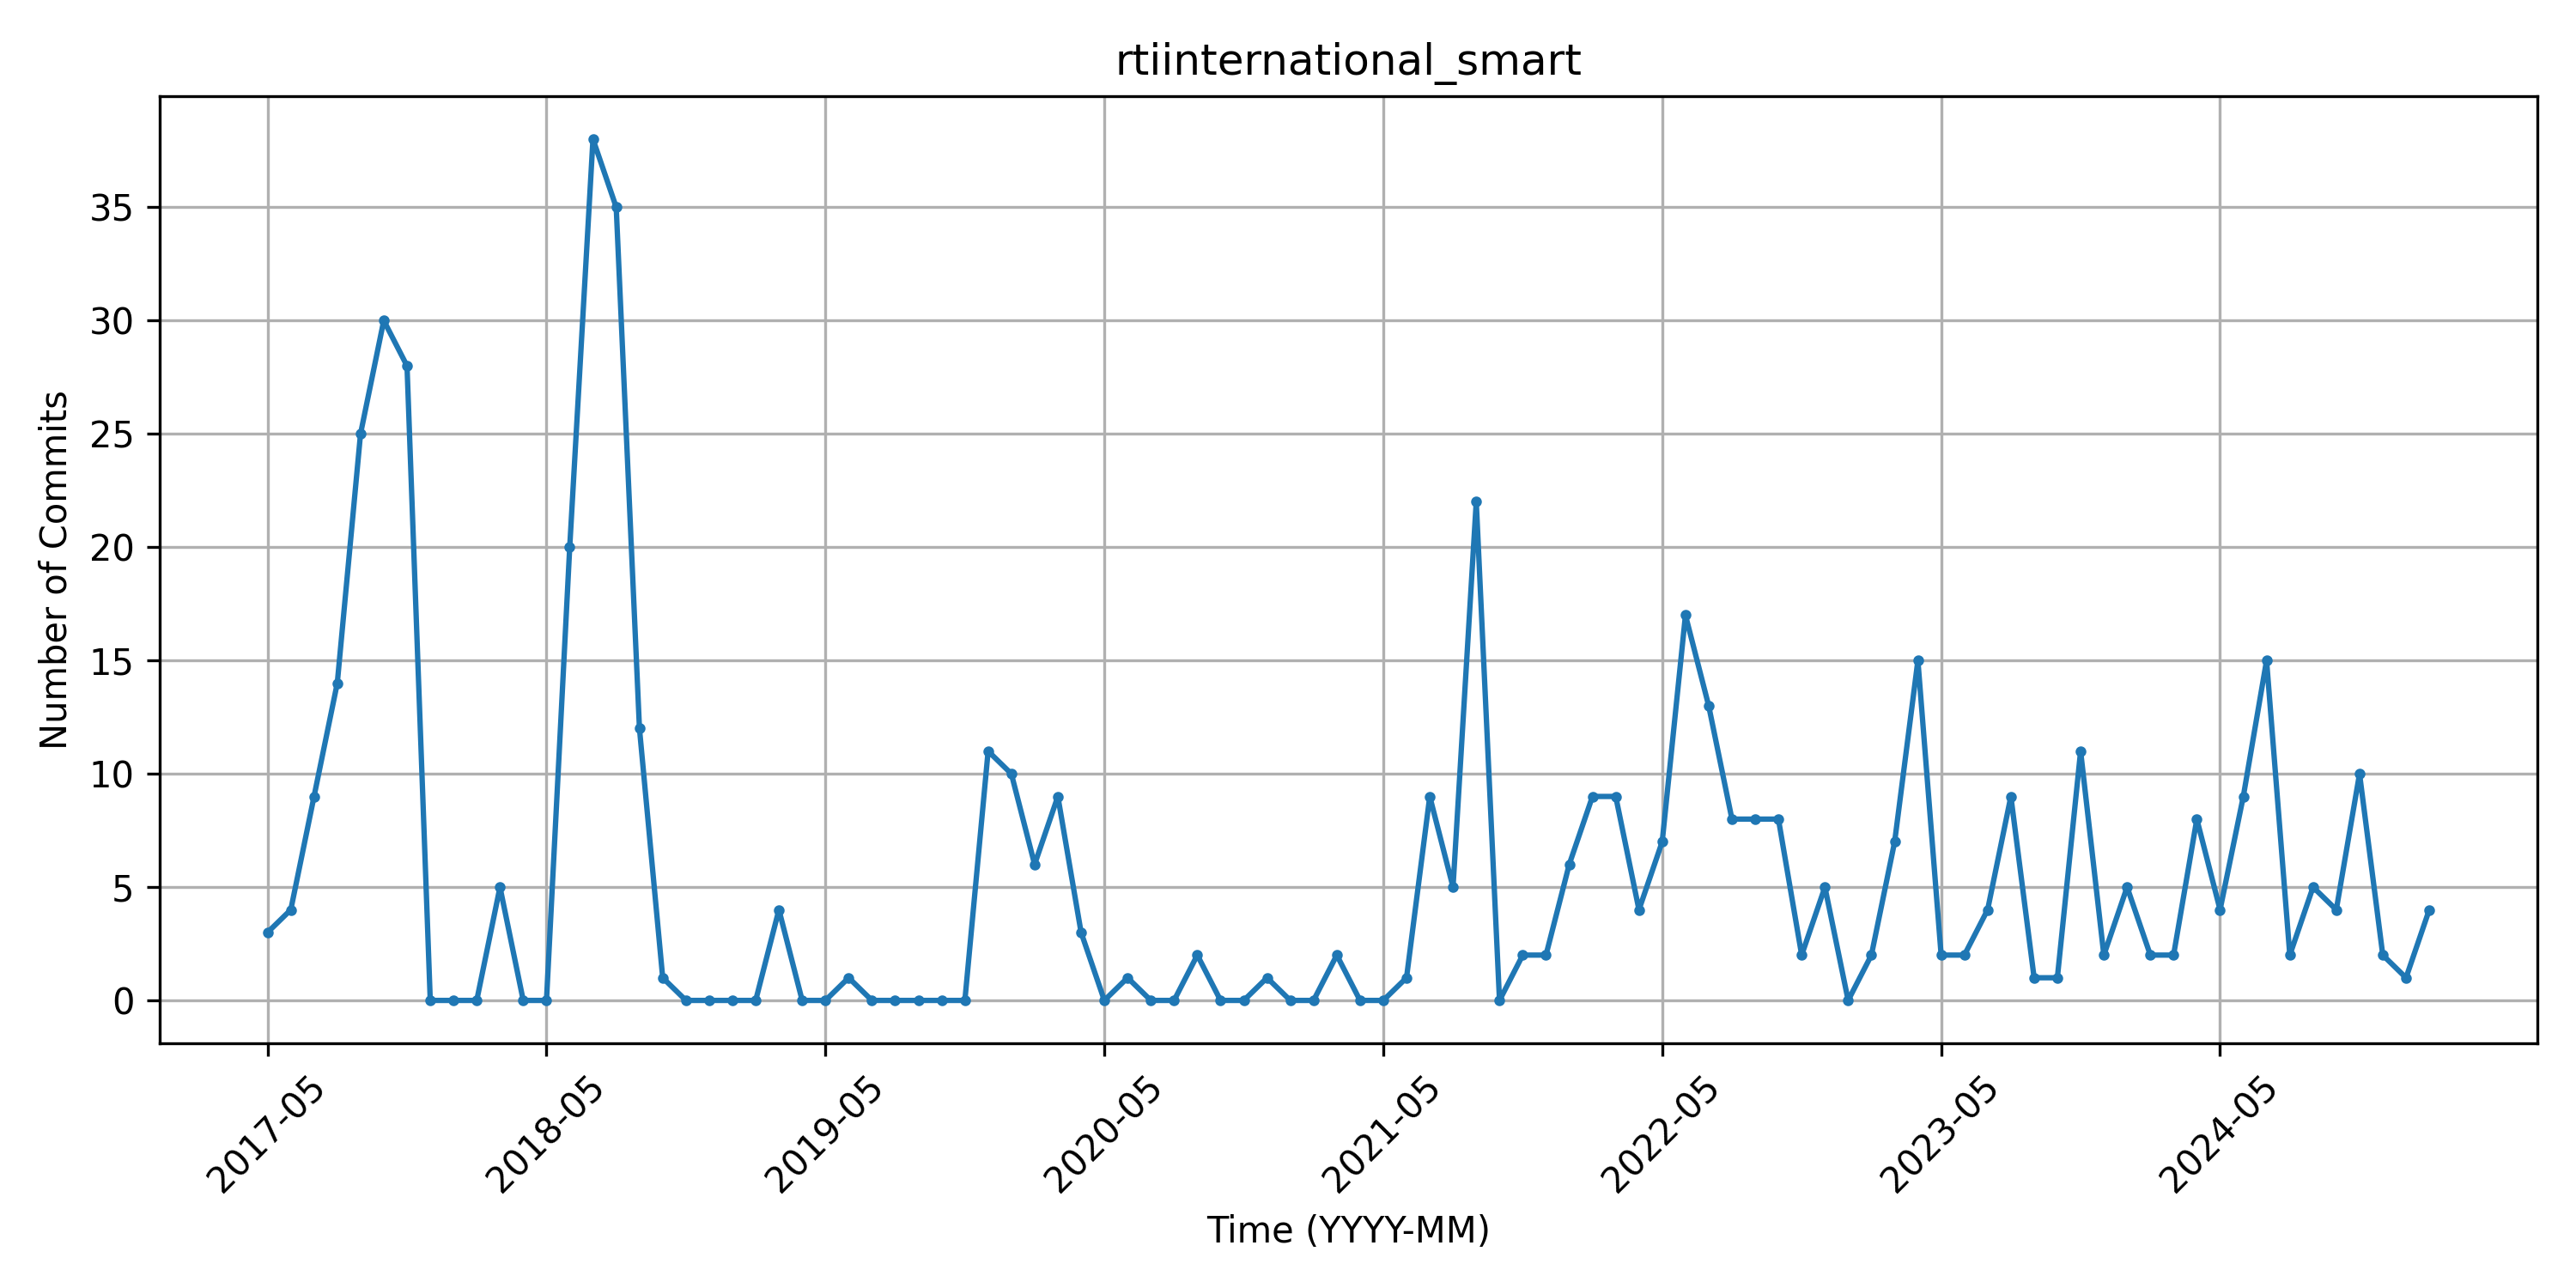

jannisborn_covid_detector


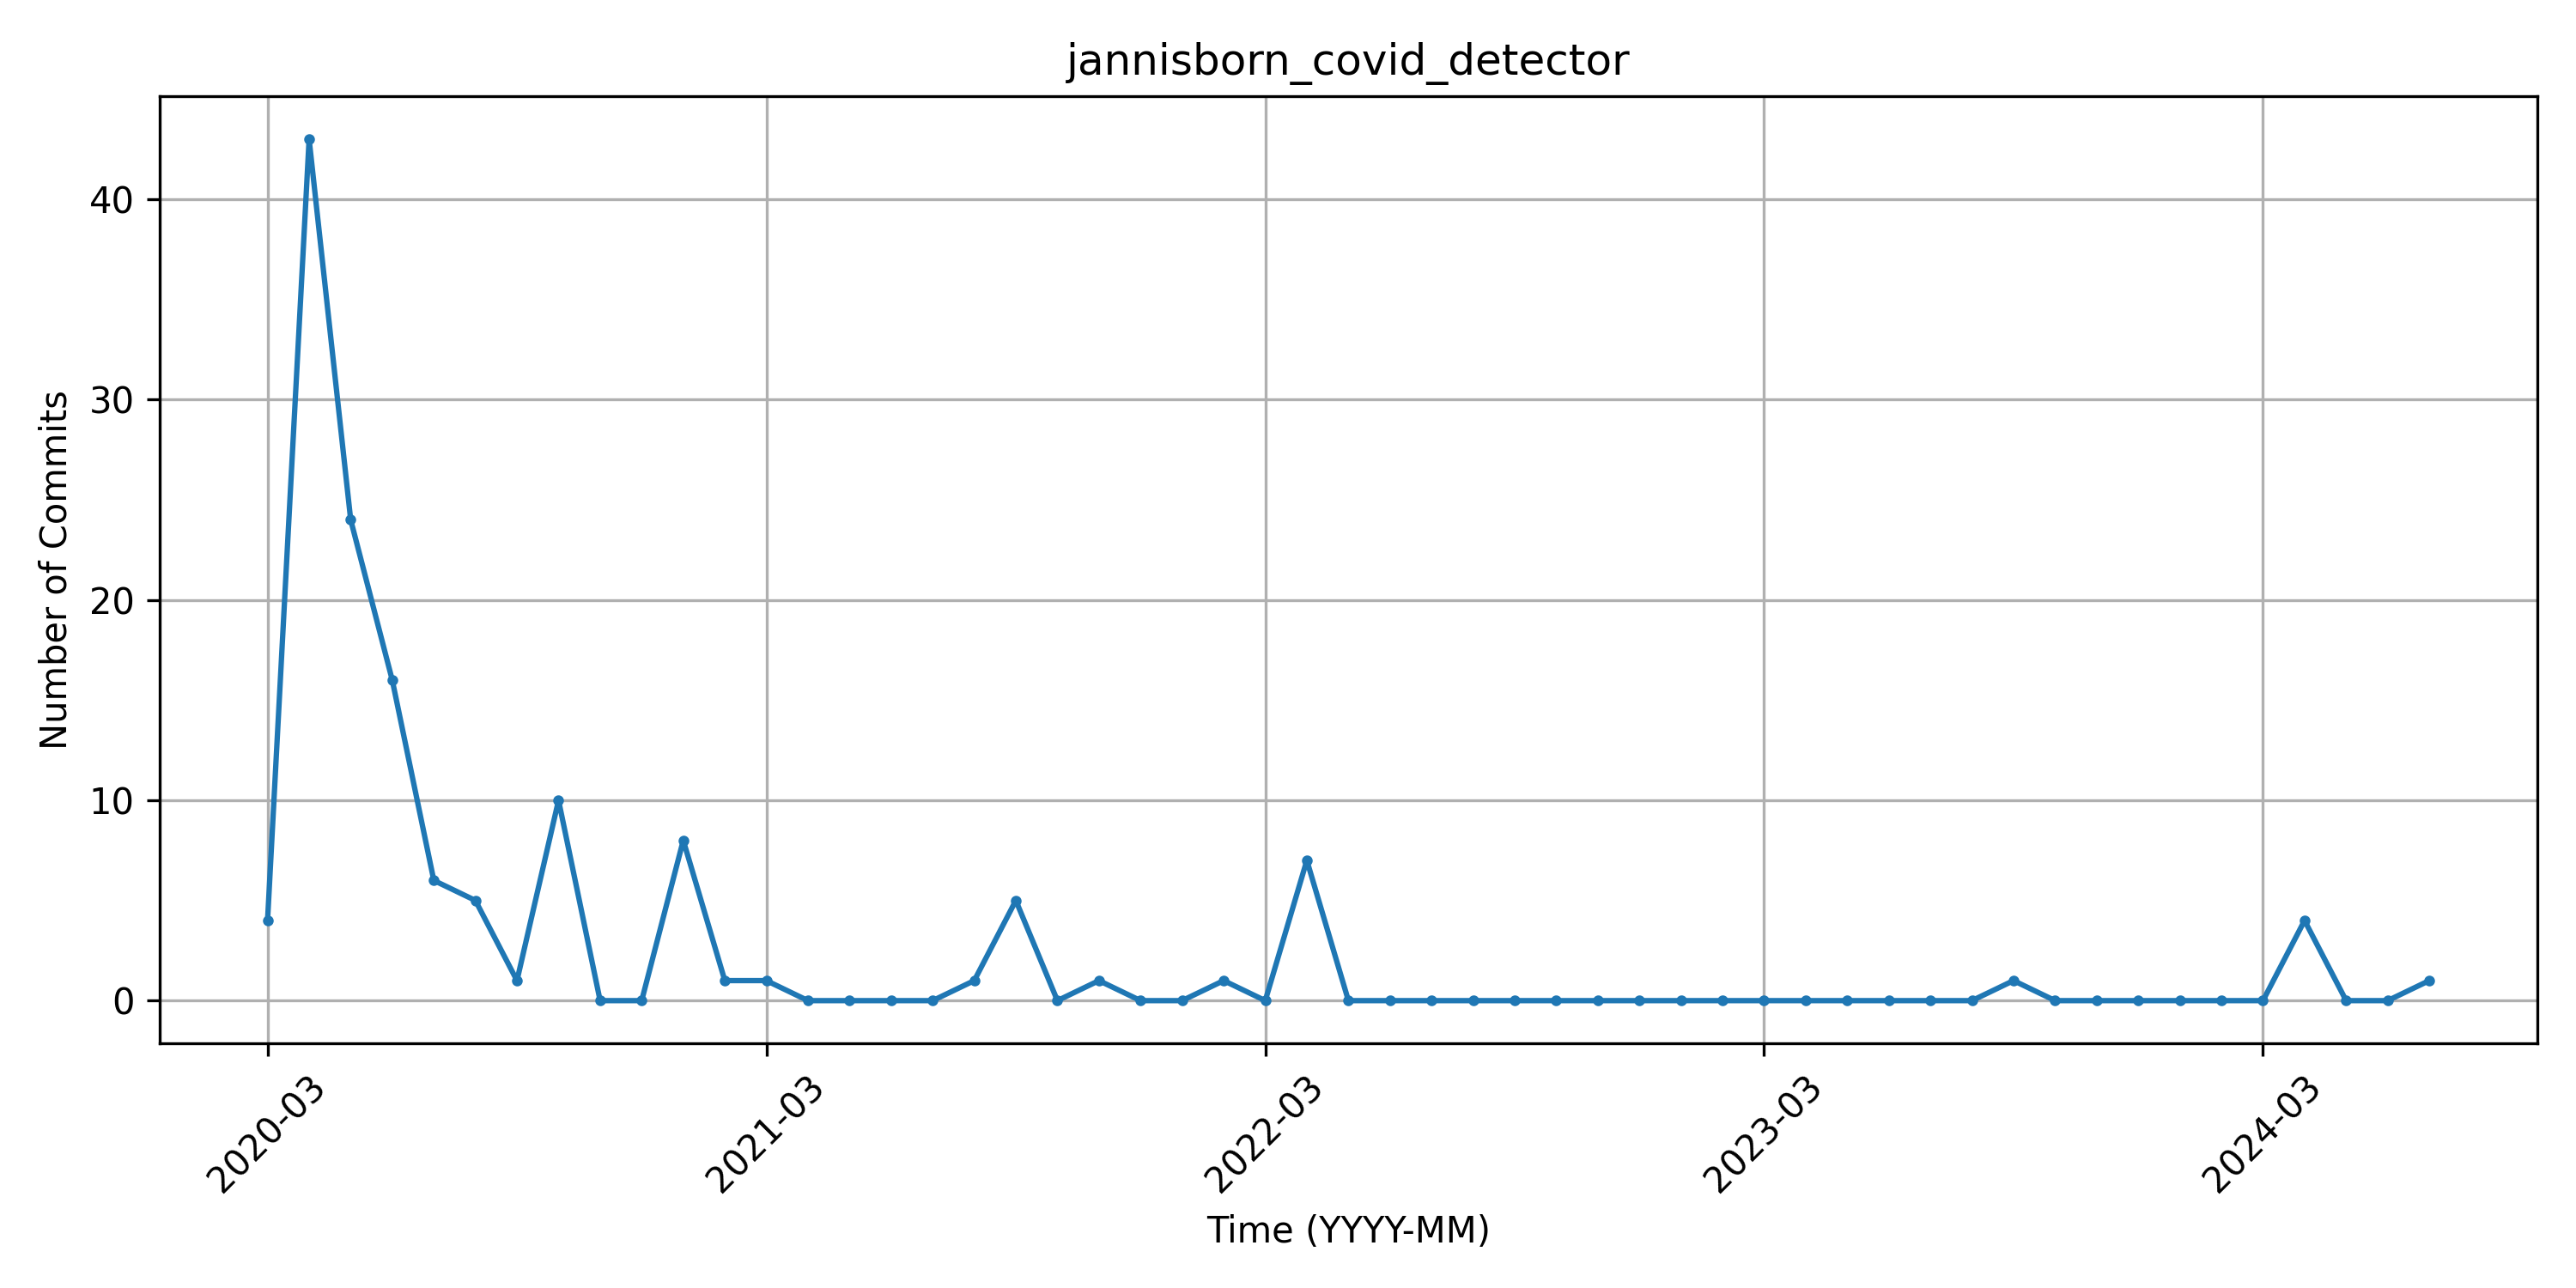

overlordgolddragon_ssqueezepy


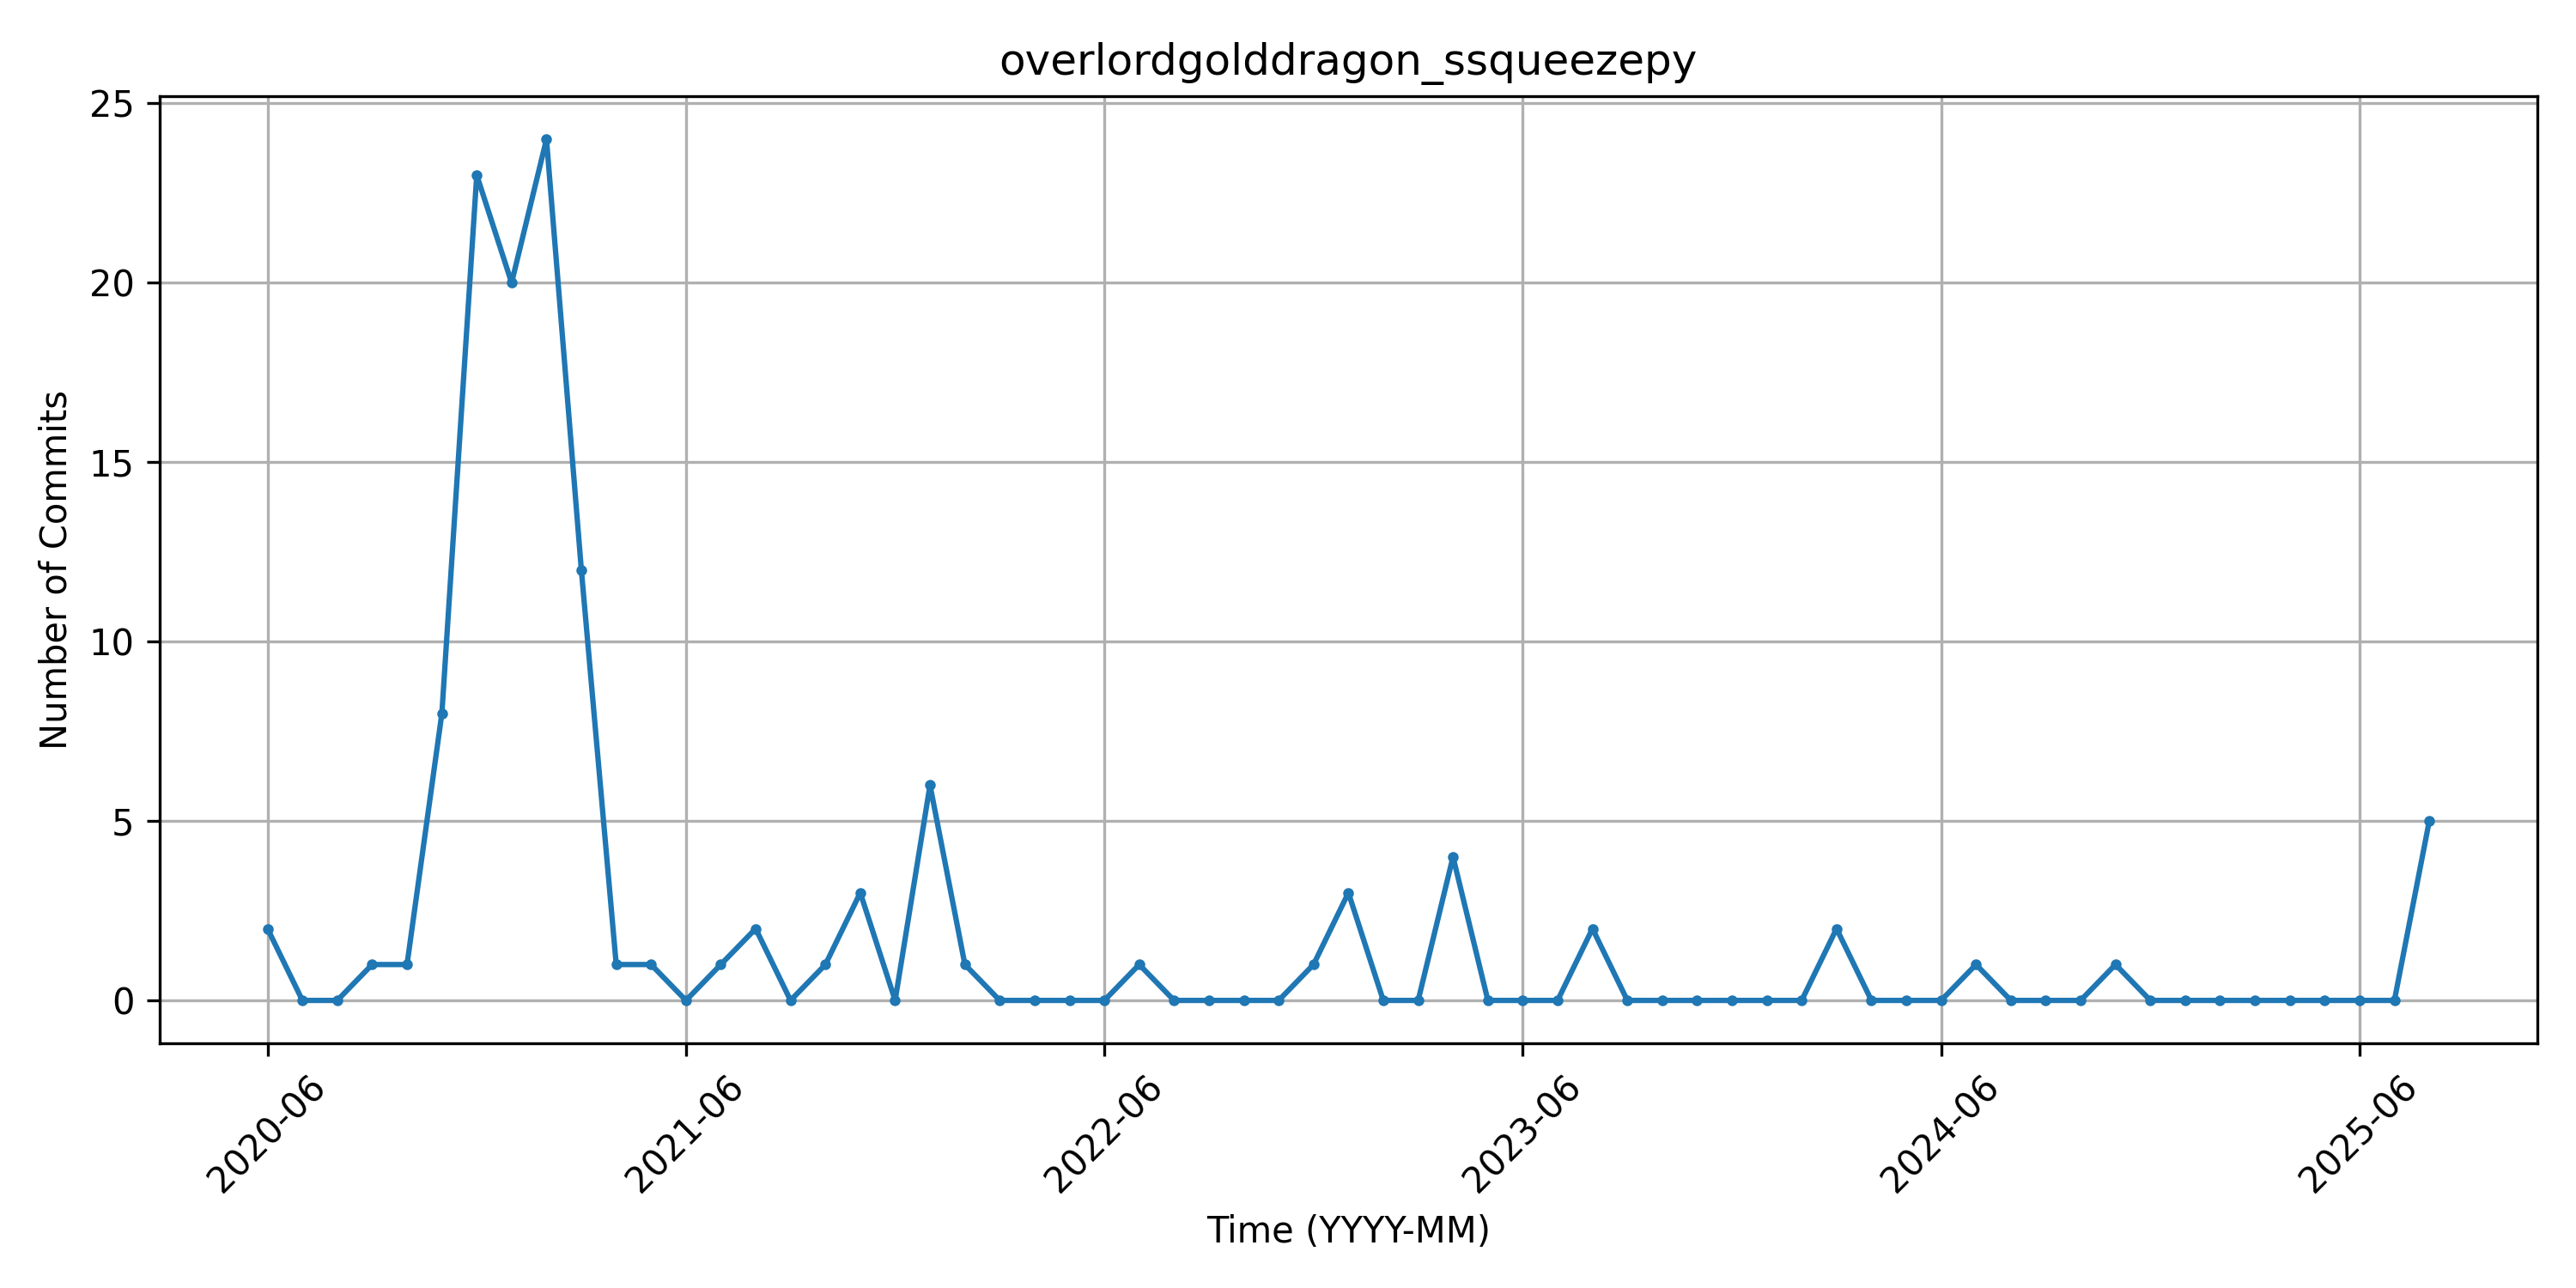

rust-bio_rust-bio


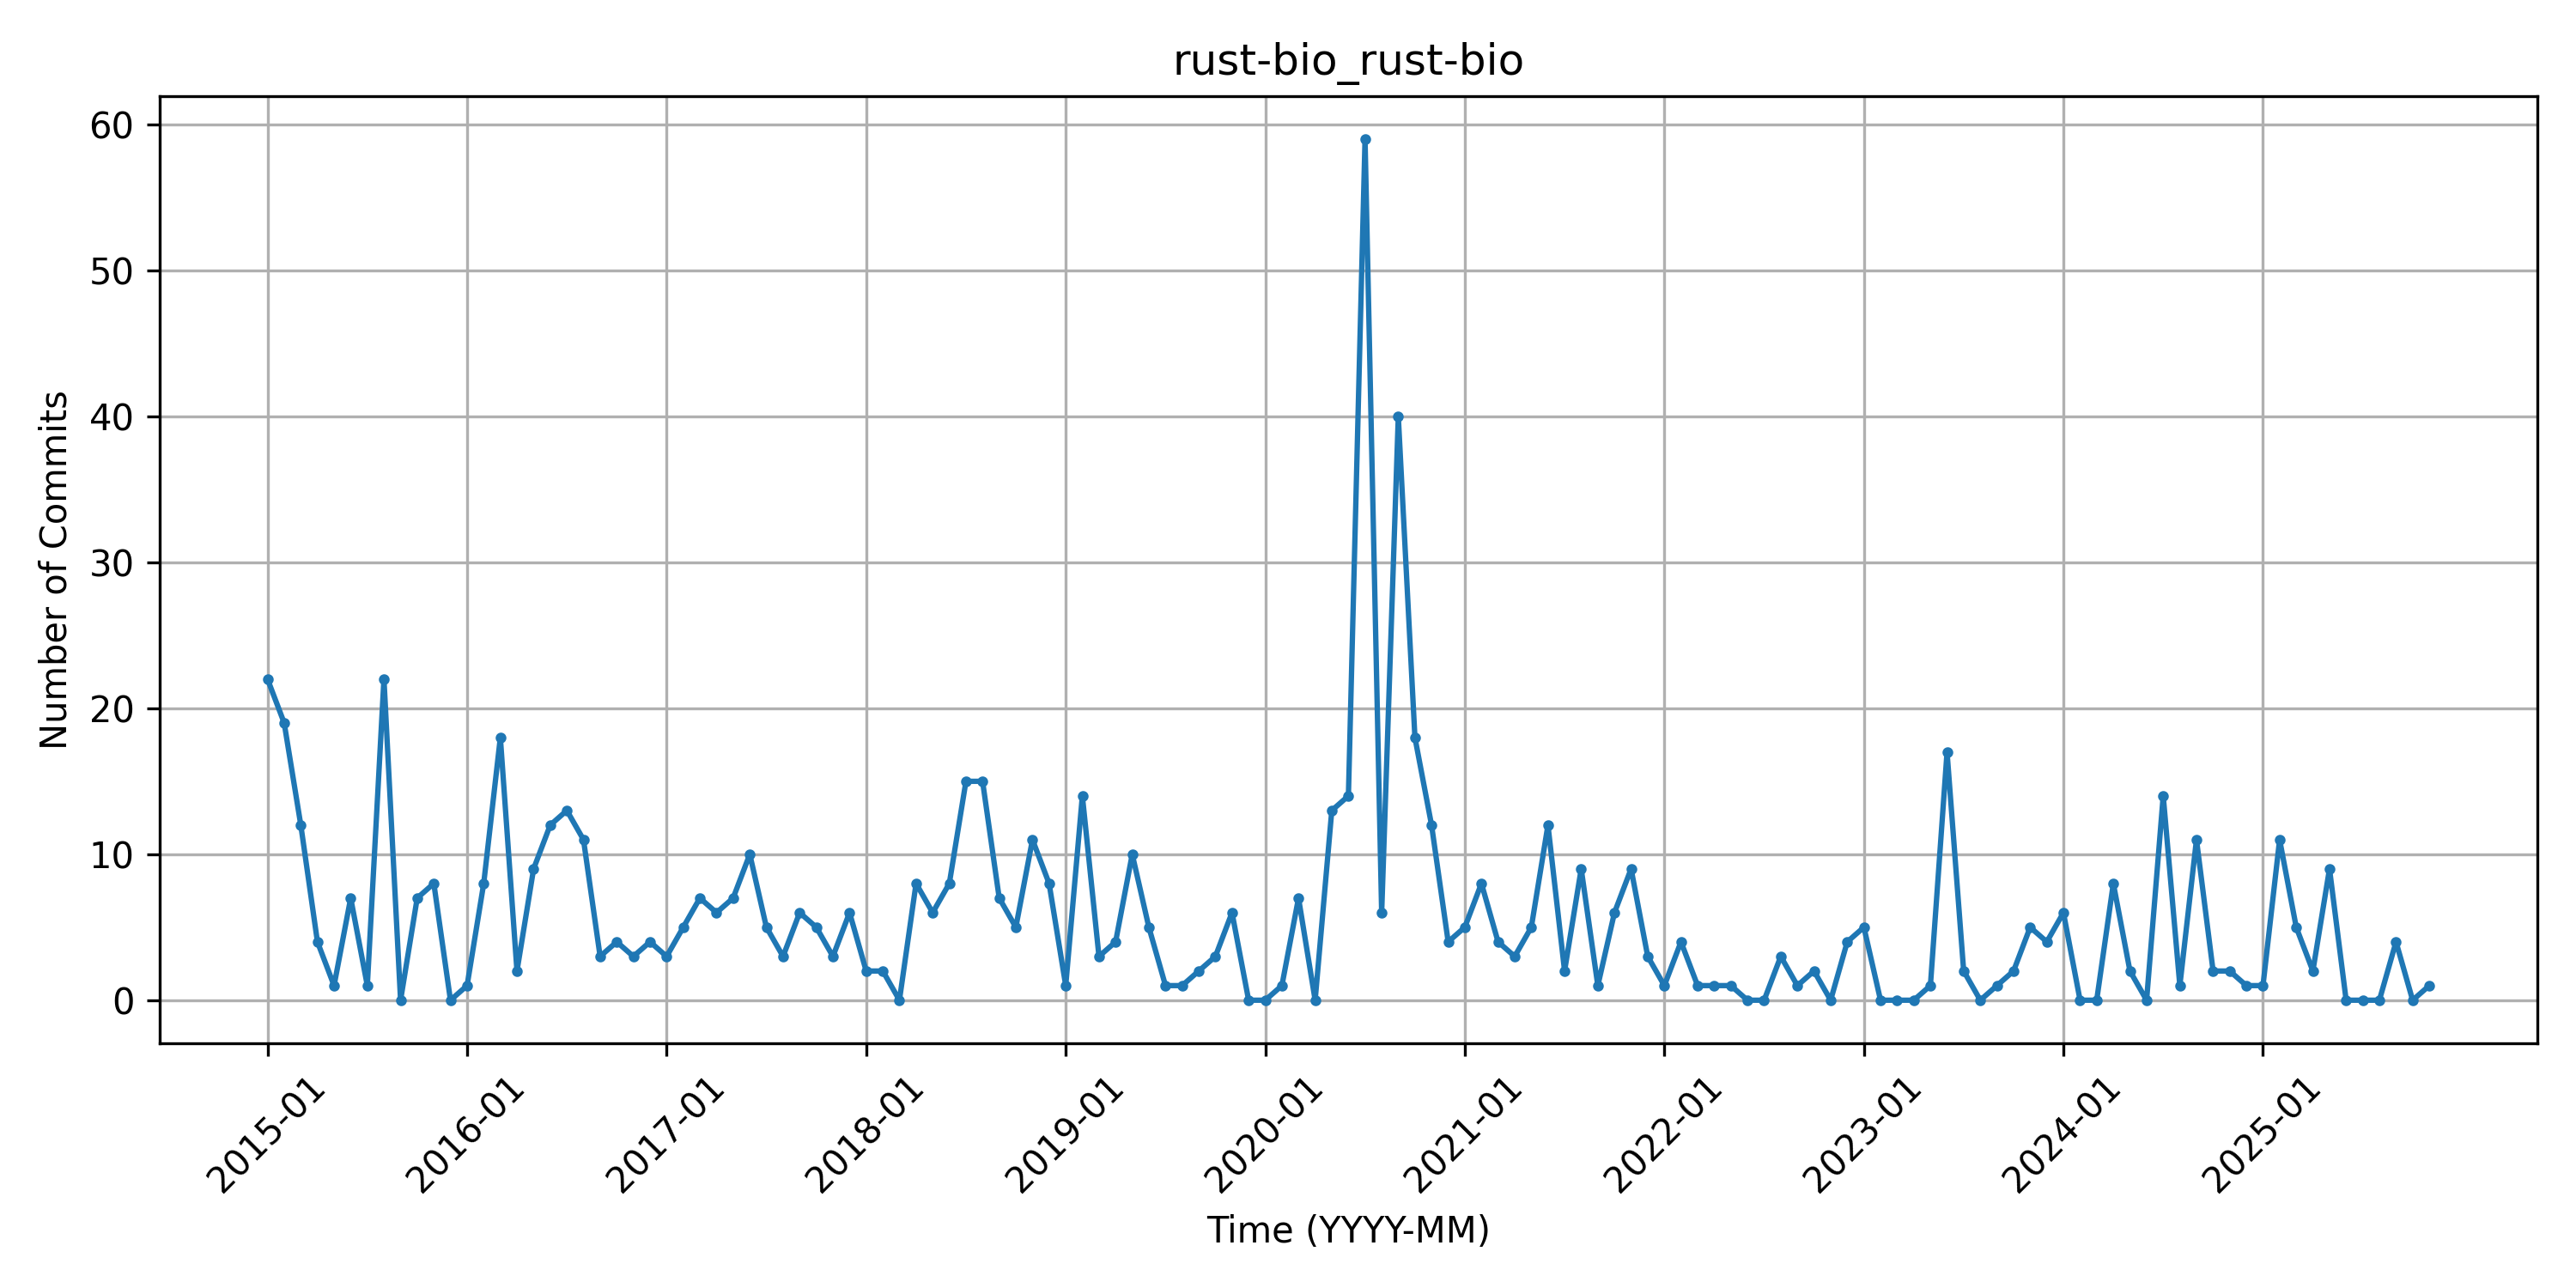

ccsb-scripps_autodock-gpu


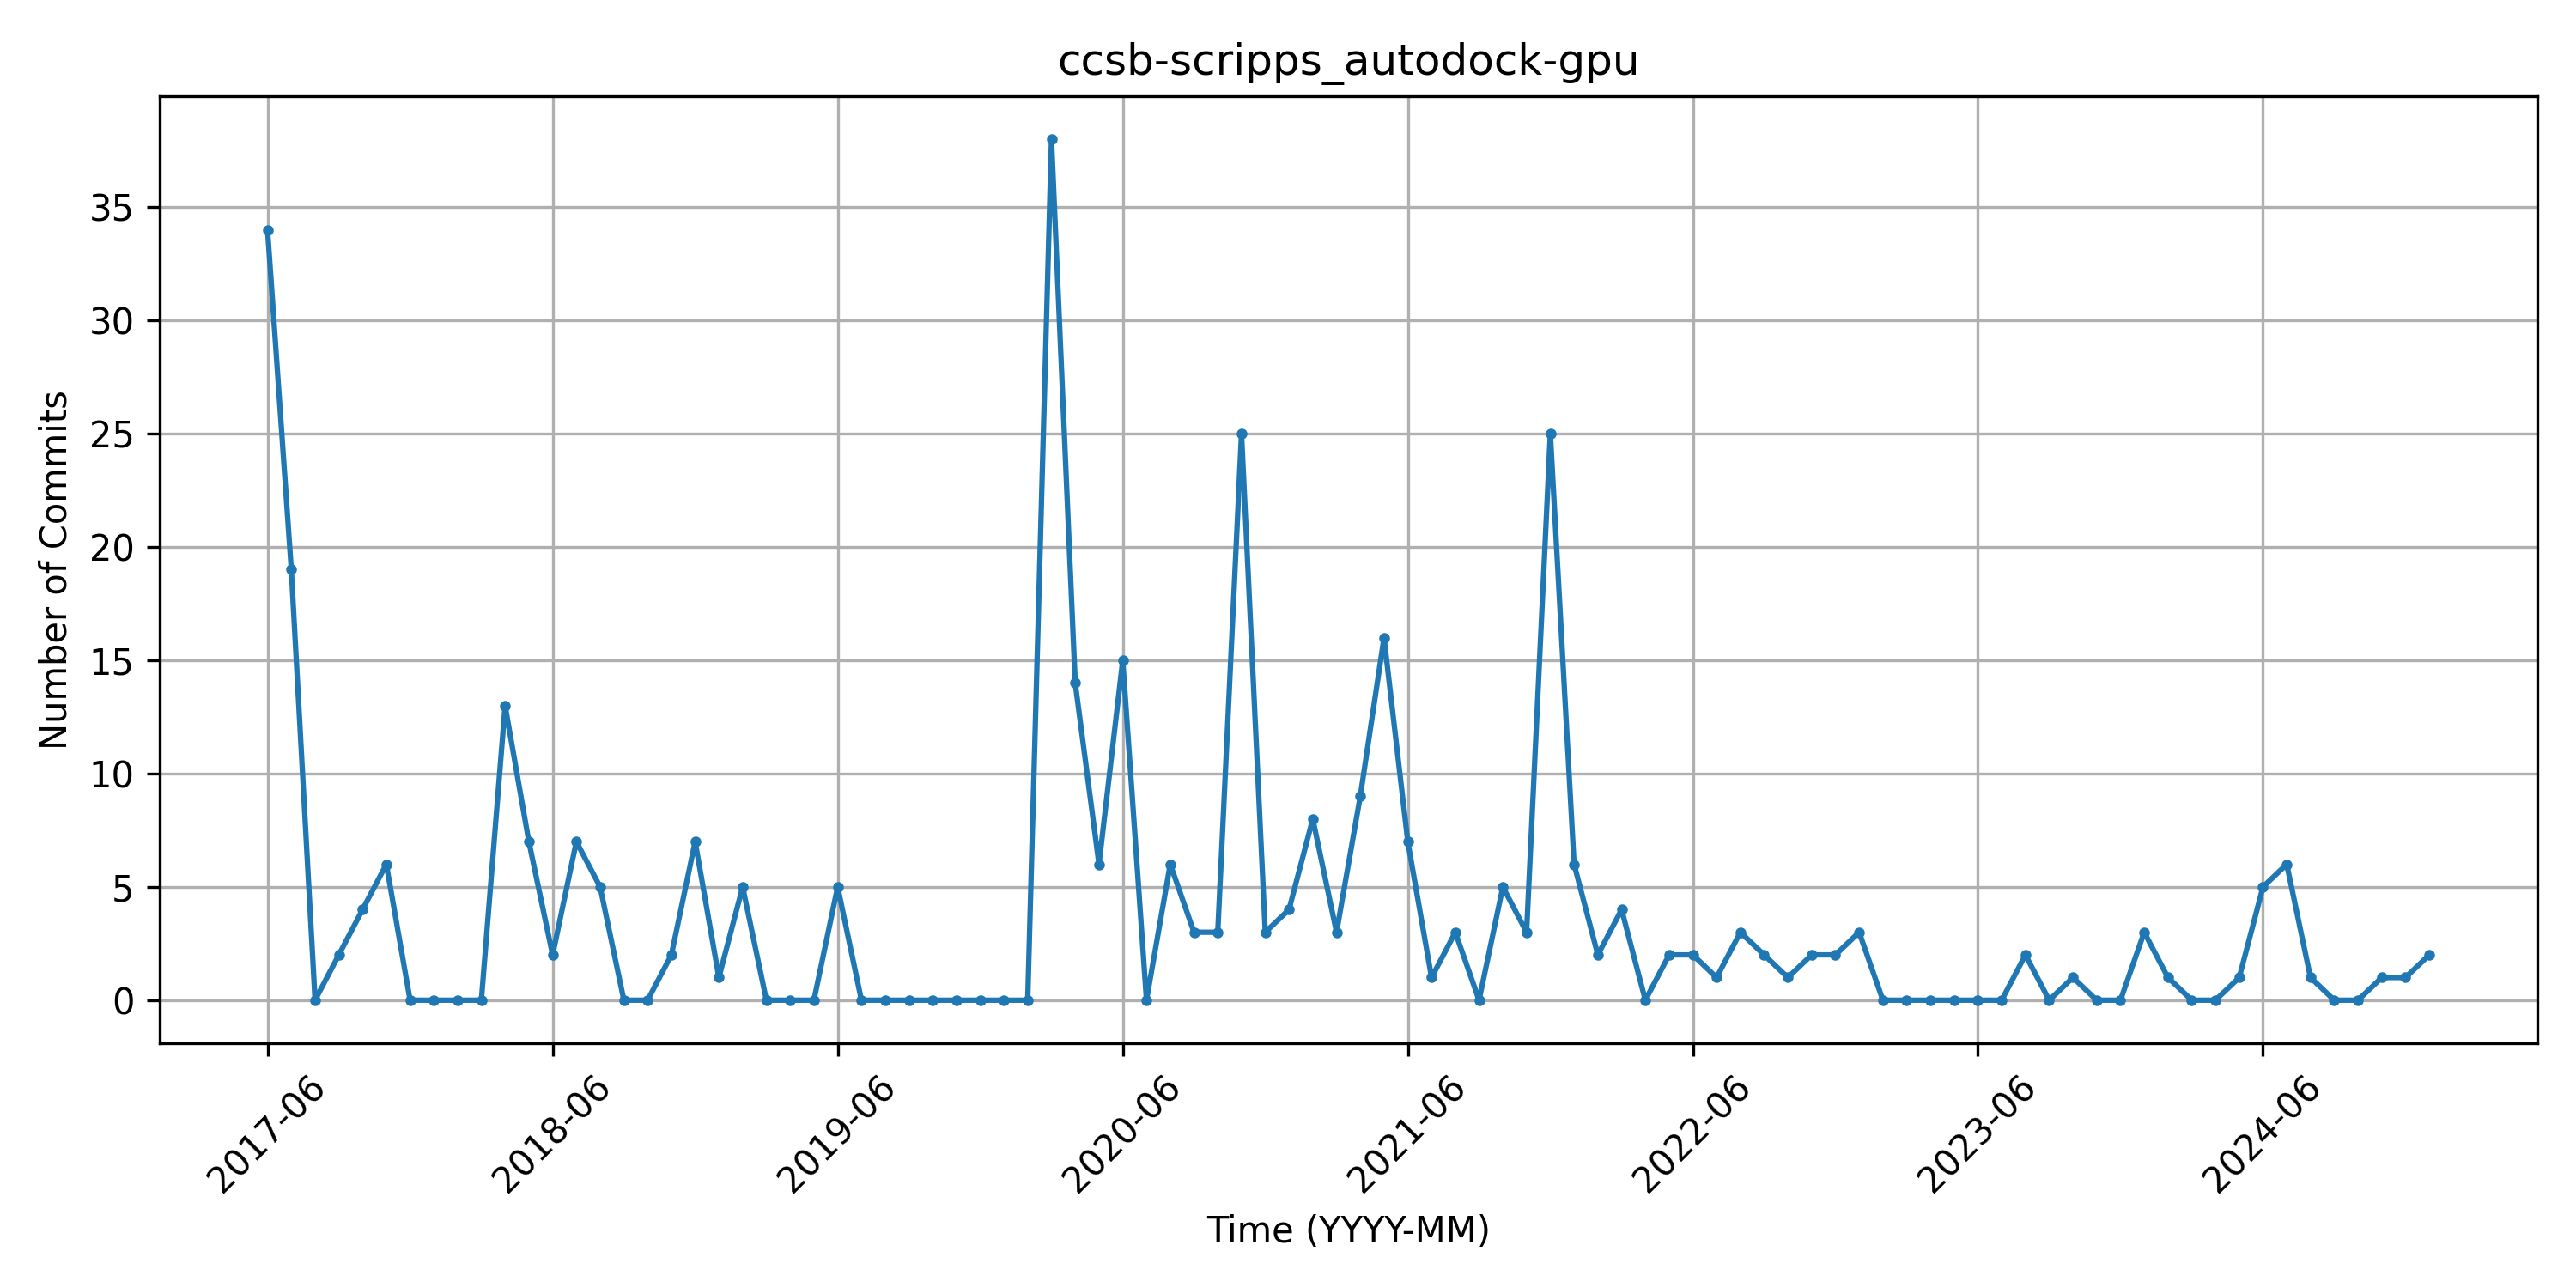

ebivariation_eva-tools


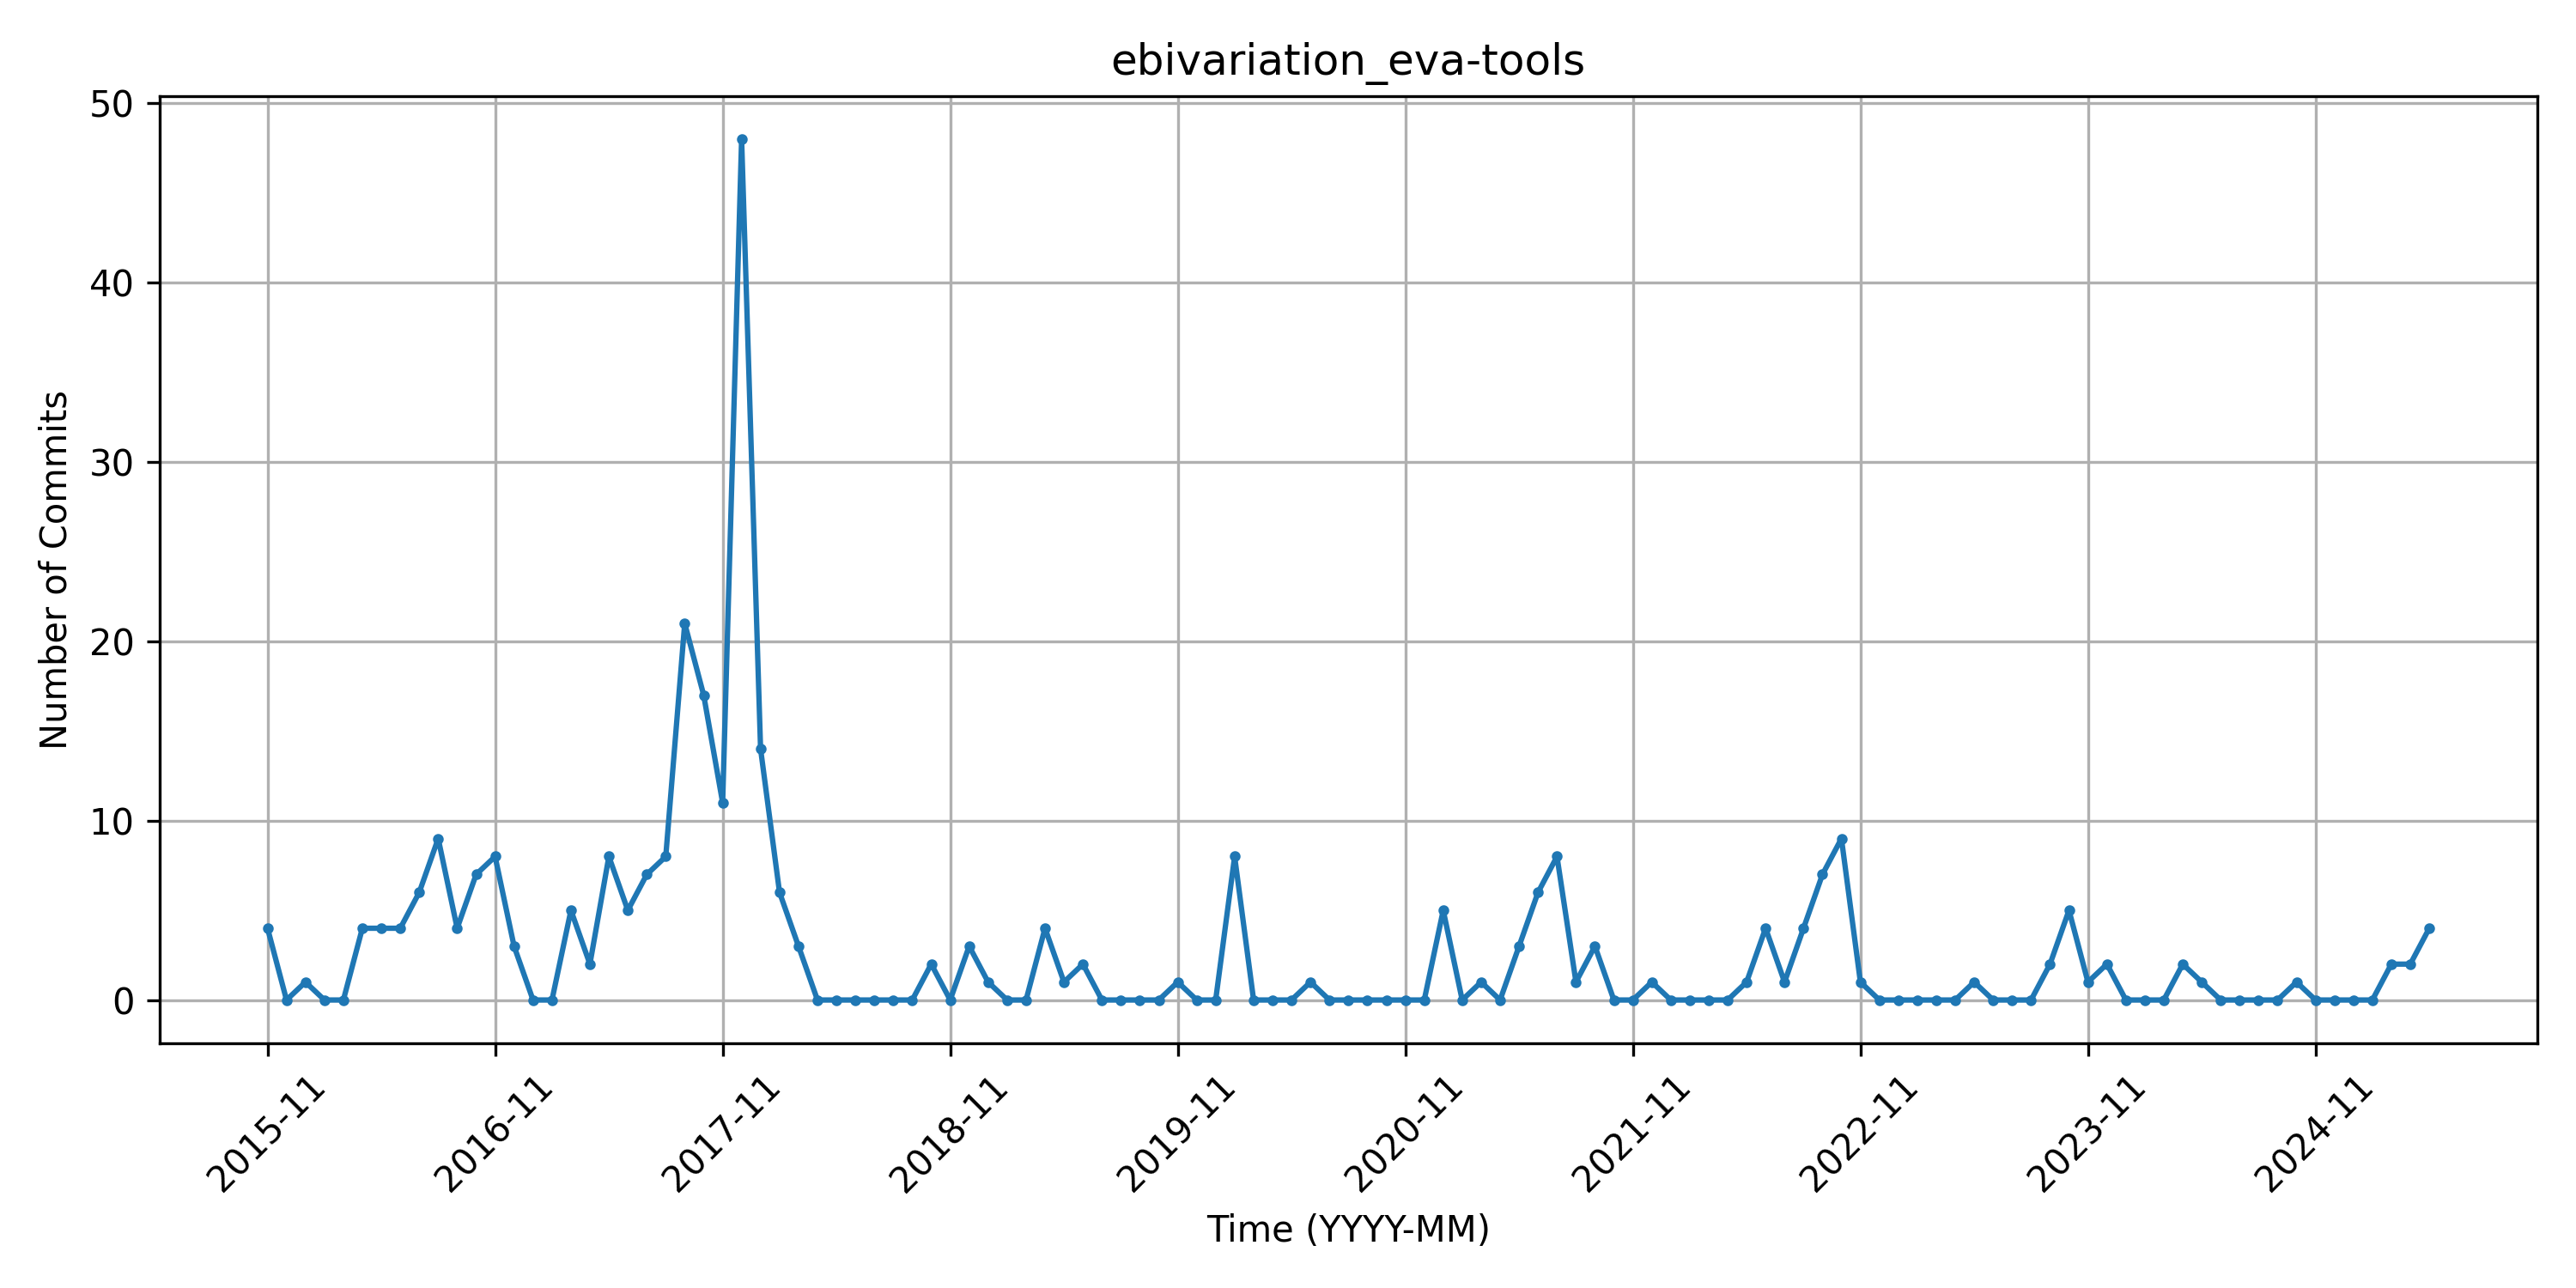

opendatacube_datacube-alchemist


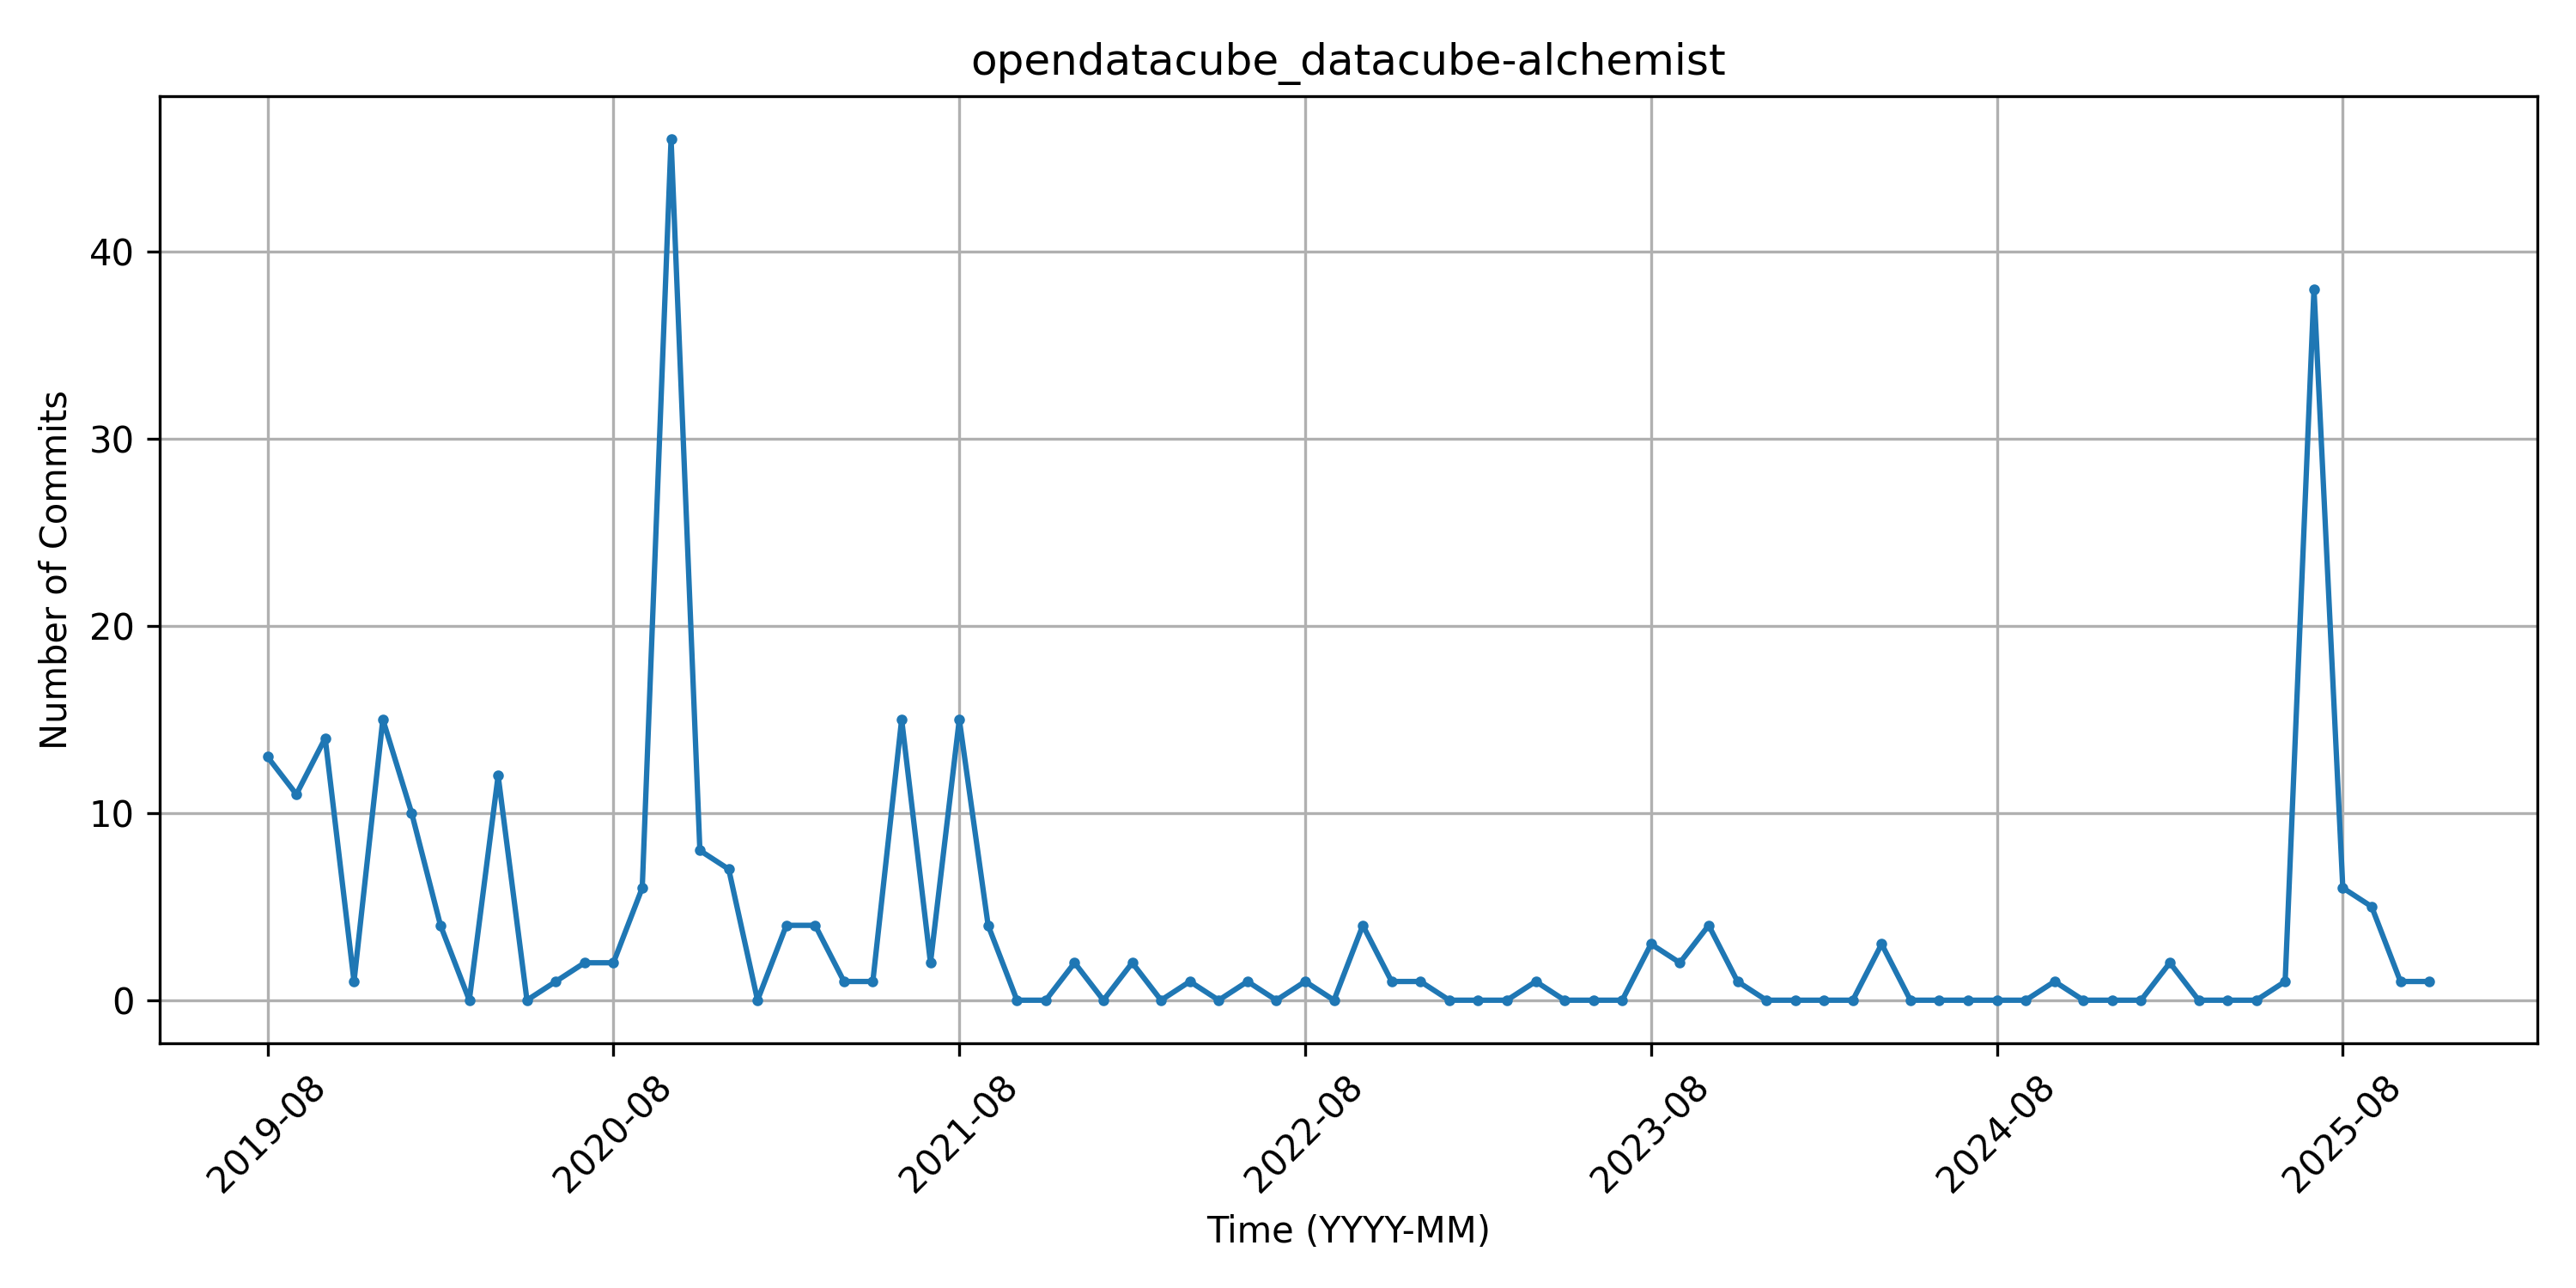

In [8]:
from IPython.display import display, Image

for project in monthly_data:
    print(project)
    display(Image(filename=f"pvathana_timeseries_{project}.png"))

In [5]:
stats = []

for project, monthly_df in monthly_data.items():
    project_df = df[df["project_wocid"] == project]

    gaps = []
    gap_start = None
    gap_length = 0

    for i, row in monthly_df.iterrows():
        if row["#Commits"] == 0:
            if gap_start is None:
                gap_start = row["Month"]
            gap_length += 1
        else:
            if gap_length > 0:
                gaps.append((gap_start, monthly_df.iloc[i - 1]["Month"], gap_length))
            gap_start = None
            gap_length = 0

    if gap_length > 0:
        gaps.append((gap_start, monthly_df.iloc[-1]["Month"], gap_length))

    longest = max(gaps, key=lambda x: x[2]) if gaps else (None, None, 0)

    if longest[1] is None:
        commits_after = 0
    else:
        commits_after = monthly_df.loc[
            monthly_df["Month"] > longest[1], "#Commits"
        ].sum()

    times = pd.to_datetime(project_df["time"], unit="s", utc=True)

    stats.append({
        "project": project,
        "number of commits": project_df["commit_sha1"].nunique(),
        "number of authors": project_df["author"].nunique(),
        "max time": times.max().strftime("%Y-%m-%d %H:%M:%S"),
        "min time": times.min().strftime("%Y-%m-%d %H:%M:%S"),
        "LongestGapStart": longest[0],
        "LongestGapEnd": longest[1],
        "LongestGapLength": longest[2],
        "NumCommitsAfterLastGap": int(commits_after),
        "NumberOfGapsInTimeline": sum(g[2] >= 3 for g in gaps)
    })

stats_df = pd.DataFrame(stats)
stats_df

,project,number of commits,number of authors,max time,min time,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline
0,mucollective_multidy,120,15,2025-10-08 20:48:42,2019-06-10 14:19:20,2023-04,2024-06,15,11,3
1,askurz_doing-bayesian-data-analysis-in-brms-an...,258,7,2025-04-15 14:27:35,2018-07-30 23:54:19,2023-02,2024-03,14,18,7
2,esmvalgroup_esmvaltool,10353,295,2026-04-17 11:04:12,2017-01-26 14:15:37,None,None,0,0,0
3,rtiinternational_smart,540,33,2025-02-01 06:42:54,2017-05-18 17:39:52,2019-07,2019-11,5,311,3
4,jannisborn_covid_detector,140,18,2024-07-09 17:56:57,2020-03-28 15:17:49,2022-05,2023-08,16,6,3
5,overlordgolddragon_ssqueezepy,127,6,2025-08-02 02:30:27,2020-06-12 11:31:59,2024-12,2025-07,8,5,7
6,rust-bio_rust-bio,770,120,2025-11-03 04:04:38,2015-01-16 16:43:41,2023-02,2023-04,3,112,2
7,ccsb-scripps_autodock-gpu,370,25,2025-01-30 22:41:15,2017-06-13 17:36:32,2019-07,2020-02,8,251,4
8,ebivariation_eva-tools,310,29,2025-05-04 06:51:23,2015-11-02 13:59:17,2018-04,2018-09,6,101,10
9,opendatacube_datacube-alchemist,280,25,2025-11-03 17:06:22,2019-08-07 06:31:12,2024-05,2024-09,5,55,6


In [6]:
github_info = {
    "mucollective_multidy": (67, 5, "2026-09-11"),
    "askurz_doing-bayesian-data-analysis-in-brms-and-the-tidyverse": (154, 43, "2026-01-04"),
    "esmvalgroup_esmvaltool": (276, 153, "2026-09-22"),
    "rtiinternational_smart": (232, 31, "2024-12-02"),
    "jannisborn_covid_detector": (174, 81, "2025-04-18"),
    "overlordgolddragon_ssqueezepy": (805, 106, "2025-08-23"),
    "rust-bio_rust-bio": (1800, 221, "2026-09-16"),
    "ccsb-scripps_autodock-gpu": (615, 151, "2026-08-11"),
    "ebivariation_eva-tools": (1, 13, "2026-07-24"),
    "opendatacube_datacube-alchemist": (22, 6, "2026-09-28")
}

stats_df["number of stars"] = stats_df["project"].map(
    lambda p: github_info[p][0]
)
stats_df["number of forks"] = stats_df["project"].map(
    lambda p: github_info[p][1]
)
stats_df["last commit date"] = stats_df["project"].map(
    lambda p: github_info[p][2]
)

stats_df

,project,number of commits,number of authors,max time,min time,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline,number of stars,number of forks,last commit date
0,mucollective_multidy,120,15,2025-10-08 20:48:42,2019-06-10 14:19:20,2023-04,2024-06,15,11,3,67,5,2026-09-11
1,askurz_doing-bayesian-data-analysis-in-brms-an...,258,7,2025-04-15 14:27:35,2018-07-30 23:54:19,2023-02,2024-03,14,18,7,154,43,2026-01-04
2,esmvalgroup_esmvaltool,10353,295,2026-04-17 11:04:12,2017-01-26 14:15:37,None,None,0,0,0,276,153,2026-09-22
3,rtiinternational_smart,540,33,2025-02-01 06:42:54,2017-05-18 17:39:52,2019-07,2019-11,5,311,3,232,31,2024-12-02
4,jannisborn_covid_detector,140,18,2024-07-09 17:56:57,2020-03-28 15:17:49,2022-05,2023-08,16,6,3,174,81,2025-04-18
5,overlordgolddragon_ssqueezepy,127,6,2025-08-02 02:30:27,2020-06-12 11:31:59,2024-12,2025-07,8,5,7,805,106,2025-08-23
6,rust-bio_rust-bio,770,120,2025-11-03 04:04:38,2015-01-16 16:43:41,2023-02,2023-04,3,112,2,1800,221,2026-09-16
7,ccsb-scripps_autodock-gpu,370,25,2025-01-30 22:41:15,2017-06-13 17:36:32,2019-07,2020-02,8,251,4,615,151,2026-08-11
8,ebivariation_eva-tools,310,29,2025-05-04 06:51:23,2015-11-02 13:59:17,2018-04,2018-09,6,101,10,1,13,2026-07-24
9,opendatacube_datacube-alchemist,280,25,2025-11-03 17:06:22,2019-08-07 06:31:12,2024-05,2024-09,5,55,6,22,6,2026-09-28


In [13]:
activity_patterns = {
    "mucollective_multidy": "declining",
    "askurz_doing-bayesian-data-analysis-in-brms-and-the-tidyverse": "irregular",
    "esmvalgroup_esmvaltool": "irregular",
    "rtiinternational_smart": "irregular",
    "jannisborn_covid_detector": "declining",
    "overlordgolddragon_ssqueezepy": "declining",
    "rust-bio_rust-bio": "irregular",
    "ccsb-scripps_autodock-gpu": "irregular",
    "ebivariation_eva-tools": "declining",
    "opendatacube_datacube-alchemist": "irregular"
}

stats_df["ActivityPattern"] = stats_df["project"].map(activity_patterns)

stats_df.to_csv(
    "pvathana_project_stats2.csv",
    sep=",",
    index=False
)

stats_df

,project,number of commits,number of authors,max time,min time,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline,number of stars,number of forks,last commit date,ActivityPattern
0,mucollective_multidy,120,15,2025-10-08 20:48:42,2019-06-10 14:19:20,2023-04,2024-06,15,11,3,67,5,2026-09-11,declining
1,askurz_doing-bayesian-data-analysis-in-brms-an...,258,7,2025-04-15 14:27:35,2018-07-30 23:54:19,2023-02,2024-03,14,18,7,154,43,2026-01-04,irregular
2,esmvalgroup_esmvaltool,10353,295,2026-04-17 11:04:12,2017-01-26 14:15:37,None,None,0,0,0,276,153,2026-09-22,irregular
3,rtiinternational_smart,540,33,2025-02-01 06:42:54,2017-05-18 17:39:52,2019-07,2019-11,5,311,3,232,31,2024-12-02,irregular
4,jannisborn_covid_detector,140,18,2024-07-09 17:56:57,2020-03-28 15:17:49,2022-05,2023-08,16,6,3,174,81,2025-04-18,declining
5,overlordgolddragon_ssqueezepy,127,6,2025-08-02 02:30:27,2020-06-12 11:31:59,2024-12,2025-07,8,5,7,805,106,2025-08-23,declining
6,rust-bio_rust-bio,770,120,2025-11-03 04:04:38,2015-01-16 16:43:41,2023-02,2023-04,3,112,2,1800,221,2026-09-16,irregular
7,ccsb-scripps_autodock-gpu,370,25,2025-01-30 22:41:15,2017-06-13 17:36:32,2019-07,2020-02,8,251,4,615,151,2026-08-11,irregular
8,ebivariation_eva-tools,310,29,2025-05-04 06:51:23,2015-11-02 13:59:17,2018-04,2018-09,6,101,10,1,13,2026-07-24,declining
9,opendatacube_datacube-alchemist,280,25,2025-11-03 17:06:22,2019-08-07 06:31:12,2024-05,2024-09,5,55,6,22,6,2026-09-28,irregular


## Interpretation

Looking at the plots, I noticed that most projects don't have consistent commit activity. Some were really active in the beginning and slowed down over time, while others had random spikes in commits throughout the years.

**1. mucollective_multidy — Declining**

This project had more commits between 2019 and 2022, but after that, activity started to slow down. There weren't many commits in the later years, especially between April 2023 and June 2024, when there was no activity for 15 months. Overall, I would consider this a declining pattern. It had **3 gaps** lasting at least 3 months.

**2. askurz_doing-bayesian-data-analysis-in-brms-and-the-tidyverse — Irregular**

The commits for this project were pretty inconsistent. There were some big spikes around 2019 and 2020, but also a lot of months with no commits. After 2022, there was barely any activity except for a few random spikes. I classified it as irregular because there wasn't a consistent pattern. It had **7 gaps** lasting at least 3 months.

**3. esmvalgroup_esmvaltool — Irregular**

This project had the most commits out of all 10 projects, with 10,353 commits. There was a huge increase in activity around 2019, with one month having over 500 commits. After that, activity dropped but continued pretty consistently compared to the other projects. What stood out to me was that this project never had a month with zero commits. It had **0 gaps** lasting at least 3 months.

**4. rtiinternational_smart — Irregular**

This project was pretty active in 2017 and 2018, but slowed down during 2019 and 2020. Activity started picking up again around 2021, although the number of commits kept going up and down. I would say the pattern is irregular since the activity changes a lot throughout the years. It had **3 gaps** lasting at least 3 months.

**5. jannisborn_covid_detector — Declining**

Most of the commits happened when the project first started in 2020. There was one month with over 40 commits, but the activity dropped pretty quickly afterward. After 2021, there were barely any commits, and the longest inactive period was 16 months. This looks like a clear declining pattern to me. It had **3 gaps** lasting at least 3 months.

**6. overlordgolddragon_ssqueezepy — Declining**

This project had most of its activity around 2020, reaching about 24 commits in one month. After that, the number of commits dropped a lot, with only a few commits here and there in later years. Since the project never really returned to its earlier activity level, I classified it as declining. It had **7 gaps** lasting at least 3 months.

**7. rust-bio_rust-bio — Irregular**

Unlike some of the other projects, rust-bio stayed active for most of the years shown in the plot. However, the number of commits changed quite a bit from month to month. There was a big spike in 2020 with almost 60 commits in one month. Activity became lower after 2021, but the project still received commits through 2025. I classified it as irregular, and it had **2 gaps** lasting at least 3 months.

**8. ccsb-scripps_autodock-gpu — Irregular**

This project had several noticeable spikes, especially around 2017, 2020, and 2021. Some months had a lot of commits, while others had very few or none at all. After 2022, the activity was generally much lower. I chose irregular because the spikes didn't seem to follow any repeating pattern. It had **4 gaps** lasting at least 3 months.

**9. ebivariation_eva-tools — Declining**

Activity increased during 2016 and 2017, with one month reaching almost 50 commits. After 2017, the number of commits dropped significantly. There were still some small spikes in later years, but nothing close to the earlier activity. I classified this as declining. It had **10 gaps** lasting at least 3 months.

**10. opendatacube_datacube-alchemist — Irregular**

This project was fairly active in 2019 and 2020, including a spike of over 40 commits in 2020. After that, activity stayed pretty low for several years. Interestingly, there was another large spike in 2025, even after a long period of very little activity. I classified it as irregular because the activity was unpredictable. It had **6 gaps** lasting at least 3 months.

### Overall Observation

Overall, most of these projects seem to have either irregular or declining commit activity. A common thing I noticed was that many projects had a lot of commits during certain periods, followed by months with little or no activity. ESMValTool was the biggest exception because it had commits every month, even though its activity level changed over time. I also didn't notice any clear seasonal or repeating patterns in the plots. Most of the spikes seemed to happen at random rather than at regular intervals.